# Task 2 — Leakage-Safe EEG Baselines + Hybrid ST-GNN

**Presentation date:** Saturday, 1 August  
**Dataset:** PhysioNet EEG Motor Movement/Imagery Database (EEGMMIDB)  
**Primary task:** Left-fist versus right-fist motor execution  
**Primary evaluation:** Subject-independent train/validation/test split

This notebook is designed to address the complete Task 2 rubric:

1. leakage-safe preprocessing and subject-independent splitting;
2. several classical and neural baselines;
3. full evaluation metrics plus training/inference time;
4. a clearly named baseline to beat;
5. explicit graph construction;
6. a visual GNN architecture diagram;
7. a regularized ST-GNN trained for **at most 20 epochs**;
8. first-results comparison against all baselines.

> The notebook targets at least 80% accuracy, but it never fabricates a result.  
> Subject-independent EEG decoding is difficult, so the measured result must be reported honestly.


## Kaggle setup

1. Open this notebook in Kaggle.
2. Attach the EEGMMIDB dataset through **Add Input**.
3. Select a GPU accelerator if available.
4. Run all cells from top to bottom.
5. Download the generated `eeg_task2_output` folder after completion.

The notebook automatically searches common Kaggle dataset paths for EDF files.


## 1. Environment and reproducibility

In [1]:
import importlib.util
import json
import os
import random
import re
import subprocess
import sys
import time
import warnings
from collections import Counter
from pathlib import Path

required_packages = {
    "mne": "mne",
    "tqdm": "tqdm",
}

for module_name, package_name in required_packages.items():
    if importlib.util.find_spec(module_name) is None:
        print(f"Installing missing package: {package_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])

import joblib
import matplotlib.pyplot as plt
import mne
import networkx as nx
import numpy as np
import pandas as pd
import scipy
import torch
import torch.nn as nn
import torch.nn.functional as F

from IPython.display import display
from mne.decoding import CSP
from scipy.linalg import eigh
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import (
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    log_loss,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
mne.set_log_level("ERROR")

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("MNE:", mne.__version__)
print("NumPy:", np.__version__)
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Python: 3.12.13
PyTorch: 2.10.0+cu128
MNE: 1.12.1
NumPy: 2.0.2
GPU available: True
GPU: Tesla T4


## 2. Configuration

In [2]:
# ----------------------------
# Main experiment selection
# ----------------------------

TASK = "LR_EXECUTION"
# Recommended for the first defensible result:
# "LR_EXECUTION"  : left fist vs right fist, physical execution
# Other supported tasks remain defined in the next section.

EVALUATION_MODE = "subject_holdout"
# "subject_holdout"   : no participant overlap; primary Task 2 result.
# "stratified_trials" : optional subject-dependent diagnostic only.

SEED = 42
QUICK_RUN = False
MAX_SUBJECTS = 20 if QUICK_RUN else 109

# EEG preprocessing
FULL_TMIN = -1.0
FULL_TMAX = 4.0
TARGET_FS = 100
MODEL_TMIN = 0.0
MODEL_TMAX = 4.0
LOW_FREQ = 8.0
HIGH_FREQ = 30.0
ARTIFACT_PTP_UV = 350.0
APPLY_COMMON_AVERAGE_REFERENCE = True

# Hybrid graph
ANATOMICAL_K = 6
FUNCTIONAL_K = 8
ANATOMICAL_WEIGHT = 0.40
FUNCTIONAL_WEIGHT = 0.60

# Deep models — hard maximum of 20 epochs
BATCH_SIZE = 64
MAX_EPOCHS = 20
EARLY_STOPPING_PATIENCE = 6
LEARNING_RATE = 2e-3
WEIGHT_DECAY = 3e-4
DROPOUT = 0.20
LABEL_SMOOTHING = 0.02
TRAIN_SEEDS = [42]
NUM_WORKERS = 2

# Baselines
RUN_XGBOOST_IF_AVAILABLE = True
RUN_CSP_LDA = True
SELECT_K_FEATURES = 384
TARGET_ACCURACY = 0.80

if Path("/kaggle/working").exists():
    OUTPUT_DIR = Path("/kaggle/working/eeg_task2_output")
else:
    OUTPUT_DIR = Path.cwd() / "eeg_task2_output"

CACHE_DIR = OUTPUT_DIR / "cache"
MODEL_DIR = OUTPUT_DIR / "models"
FIGURE_DIR = OUTPUT_DIR / "figures"
for directory in (OUTPUT_DIR, CACHE_DIR, MODEL_DIR, FIGURE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = DEVICE.type == "cuda"

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

seed_everything(SEED)

print("Task:", TASK)
print("Evaluation:", EVALUATION_MODE)
print("Maximum epochs:", MAX_EPOCHS)
print("Device:", DEVICE)
print("Output:", OUTPUT_DIR)


Task: LR_EXECUTION
Evaluation: subject_holdout
Maximum epochs: 20
Device: cuda
Output: /kaggle/working/eeg_task2_output


## 3. Task definitions and label integrity

In [3]:
TASK_DEFINITIONS = {
    "LR_EXECUTION": {
        "runs": {3, 7, 11},
        "class_names": ["Left fist", "Right fist"],
        "mode": "binary",
    },
    "LR_IMAGERY": {
        "runs": {4, 8, 12},
        "class_names": ["Imagined left fist", "Imagined right fist"],
        "mode": "binary",
    },
    "BF_EXECUTION": {
        "runs": {5, 9, 13},
        "class_names": ["Both fists", "Both feet"],
        "mode": "binary",
    },
    "BF_IMAGERY": {
        "runs": {6, 10, 14},
        "class_names": ["Imagined both fists", "Imagined both feet"],
        "mode": "binary",
    },
    "LR_COMBINED": {
        "runs": {3, 4, 7, 8, 11, 12},
        "class_names": ["Left fist", "Right fist"],
        "mode": "binary",
    },
    "BF_COMBINED": {
        "runs": {5, 6, 9, 10, 13, 14},
        "class_names": ["Both fists", "Both feet"],
        "mode": "binary",
    },
    "FOUR_CLASS_LR": {
        "runs": {3, 4, 7, 8, 11, 12},
        "class_names": [
            "Execution-left",
            "Execution-right",
            "Imagery-left",
            "Imagery-right",
        ],
        "mode": "four_class",
    },
    "FOUR_CLASS_BF": {
        "runs": {5, 6, 9, 10, 13, 14},
        "class_names": [
            "Execution-fists",
            "Execution-feet",
            "Imagery-fists",
            "Imagery-feet",
        ],
        "mode": "four_class",
    },
}

if TASK not in TASK_DEFINITIONS:
    raise ValueError(f"Unknown TASK={TASK!r}")

TASK_INFO = TASK_DEFINITIONS[TASK]
SELECTED_RUNS = TASK_INFO["runs"]
CLASS_NAMES = TASK_INFO["class_names"]
N_CLASSES = len(CLASS_NAMES)

EXECUTION_RUNS = {3, 5, 7, 9, 11, 13}
IMAGERY_RUNS = {4, 6, 8, 10, 12, 14}

def map_task_label(run, annotation):
    annotation = annotation.upper().strip()
    if annotation not in {"T1", "T2"}:
        raise ValueError(f"Unsupported annotation: {annotation}")
    event_side = 0 if annotation == "T1" else 1

    if TASK_INFO["mode"] == "binary":
        return event_side

    is_imagery = int(run in IMAGERY_RUNS)
    return is_imagery * 2 + event_side

display(pd.Series({
    "task": TASK,
    "selected_runs": sorted(SELECTED_RUNS),
    "classes": CLASS_NAMES,
    "number_of_classes": N_CLASSES,
}).to_frame("value"))

,value
task,LR_EXECUTION
selected_runs,"[3, 7, 11]"
classes,"[Left fist, Right fist]"
number_of_classes,2


## 4. Locate and index the raw EDF dataset

In [4]:
CANONICAL_FILE_PATTERN = re.compile(
    r"S(?P<subject>\d{3})R(?P<run>\d{2})\.edf$",
    flags=re.IGNORECASE,
)

def locate_edf_files():
    preferred_roots = [
        Path("/kaggle/input/physionet-eeg-motor-movement-imagery"),
        Path("/kaggle/input/eeg-motor-movementimagery-dataset"),
        Path("/kaggle/input"),
        Path("/content"),
        Path.cwd(),
    ]

    custom_root = os.environ.get("EEGMMIDB_ROOT")
    if custom_root:
        preferred_roots.insert(0, Path(custom_root))

    found = []
    visited = set()
    for root in preferred_roots:
        if not root.exists():
            continue
        root_key = str(root.resolve())
        if root_key in visited:
            continue
        visited.add(root_key)
        found.extend(root.rglob("*.edf"))
        found.extend(root.rglob("*.EDF"))

    canonical = []
    seen = set()
    for path in found:
        match = CANONICAL_FILE_PATTERN.search(path.name)
        if match:
            resolved = str(path.resolve())
            if resolved not in seen:
                canonical.append(path.resolve())
                seen.add(resolved)

    return sorted(canonical)

EDF_FILES = locate_edf_files()

if not EDF_FILES:
    raise FileNotFoundError(
        "No EEGMMIDB EDF files were found. On Kaggle, use Add Input and attach "
        "'gamalasran/physionet-eeg-motor-movement-imagery'."
    )

index_rows = []
for path in EDF_FILES:
    match = CANONICAL_FILE_PATTERN.search(path.name)
    if match:
        index_rows.append({
            "path": str(path),
            "subject": int(match.group("subject")),
            "run": int(match.group("run")),
            "size_mb": path.stat().st_size / (1024 ** 2),
        })

record_index = pd.DataFrame(index_rows)
record_index = record_index[record_index["run"].isin(SELECTED_RUNS)].copy()
record_index = record_index.sort_values(["subject", "run"]).reset_index(drop=True)

available_subjects = sorted(record_index["subject"].unique())
selected_subjects = available_subjects[:min(MAX_SUBJECTS, len(available_subjects))]
record_index = record_index[record_index["subject"].isin(selected_subjects)].reset_index(drop=True)

print(f"Found {len(EDF_FILES):,} canonical EDF files.")
print(f"Selected {len(record_index):,} files from {len(selected_subjects)} subjects.")
display(record_index.head(12))
display(pd.crosstab(record_index["subject"], record_index["run"]).head())

Found 1,526 canonical EDF files.
Selected 327 files from 109 subjects.


,path,subject,run,size_mb
0,/kaggle/input/datasets/gamalasran/physionet-ee...,1,3,2.476593
1,/kaggle/input/datasets/gamalasran/physionet-ee...,1,7,2.476593
2,/kaggle/input/datasets/gamalasran/physionet-ee...,1,11,2.476593
3,/kaggle/input/datasets/gamalasran/physionet-ee...,2,3,2.437225
4,/kaggle/input/datasets/gamalasran/physionet-ee...,2,7,2.437225
5,/kaggle/input/datasets/gamalasran/physionet-ee...,2,11,2.437225
6,/kaggle/input/datasets/gamalasran/physionet-ee...,3,3,2.476593
7,/kaggle/input/datasets/gamalasran/physionet-ee...,3,7,2.476593
8,/kaggle/input/datasets/gamalasran/physionet-ee...,3,11,2.476593
9,/kaggle/input/datasets/gamalasran/physionet-ee...,4,3,2.437225


run,3,7,11
subject,,,
1,1,1,1
2,1,1,1
3,1,1,1
4,1,1,1
5,1,1,1


## 5. Channel normalization and epoch extraction

In [5]:
STANDARD_MONTAGE = mne.channels.make_standard_montage("standard_1005")
STANDARD_NAME_LOOKUP = {
    re.sub(r"[^a-zA-Z0-9]", "", name).lower(): name
    for name in STANDARD_MONTAGE.ch_names
}

def clean_channel_name(name):
    key = re.sub(r"[^a-zA-Z0-9]", "", name).lower()
    return STANDARD_NAME_LOOKUP.get(key, name.strip().strip("."))

def normalize_raw_channels(raw):
    rename_map = {}
    for old_name in raw.ch_names:
        new_name = clean_channel_name(old_name)
        if new_name != old_name:
            rename_map[old_name] = new_name
    if rename_map:
        raw.rename_channels(rename_map)
    raw.set_montage(STANDARD_MONTAGE, on_missing="ignore", verbose=False)
    return raw

def annotation_code_map(event_id):
    output = {}
    for description, code_value in event_id.items():
        normalized = str(description).upper().strip()
        if normalized.endswith("T1"):
            output["T1"] = code_value
        elif normalized.endswith("T2"):
            output["T2"] = code_value
    return output

def resample_epoch(epoch_uv, original_fs, target_fs, target_samples):
    if abs(original_fs - target_fs) < 1e-6 and epoch_uv.shape[-1] == target_samples:
        return epoch_uv.astype(np.float32)
    resampled = scipy.signal.resample(epoch_uv, target_samples, axis=-1)
    return resampled.astype(np.float32)

FULL_DURATION = FULL_TMAX - FULL_TMIN
FULL_SAMPLES = int(round(FULL_DURATION * TARGET_FS))

MODEL_START = int(round((MODEL_TMIN - FULL_TMIN) * TARGET_FS))
MODEL_STOP = int(round((MODEL_TMAX - FULL_TMIN) * TARGET_FS))

if not (0 <= MODEL_START < MODEL_STOP <= FULL_SAMPLES):
    raise ValueError("Invalid model crop relative to the full epoch.")

print("Full samples:", FULL_SAMPLES)
print("Model crop:", MODEL_START, MODEL_STOP, "=>", MODEL_STOP - MODEL_START, "samples")

Full samples: 500
Model crop: 100 500 => 400 samples


In [6]:
def build_preprocessed_dataset(records):
    epochs_store = []
    labels_store = []
    subjects_store = []
    runs_store = []
    annotations_store = []
    metadata_rows = []
    rejected_rows = []
    channel_names = None

    for row in tqdm(
        records.itertuples(index=False),
        total=len(records),
        desc="Extracting EEG epochs",
    ):
        path = Path(row.path)
        subject = int(row.subject)
        run = int(row.run)

        try:
            raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
            raw.pick(picks="eeg")
            raw = normalize_raw_channels(raw)

            if channel_names is None:
                channel_names = list(raw.ch_names)
                print("Reference channel count:", len(channel_names))
            else:
                missing = [name for name in channel_names if name not in raw.ch_names]
                if missing:
                    rejected_rows.append({
                        "subject": subject,
                        "run": run,
                        "reason": f"missing_channels:{','.join(missing[:5])}",
                    })
                    raw.close()
                    continue
                raw.reorder_channels(channel_names)

            if APPLY_COMMON_AVERAGE_REFERENCE:
                raw.set_eeg_reference("average", projection=False, verbose=False)

            raw.filter(
                LOW_FREQ,
                HIGH_FREQ,
                picks="eeg",
                method="iir",
                verbose=False,
            )

            events, event_id = mne.events_from_annotations(raw, verbose=False)
            codes = annotation_code_map(event_id)
            original_fs = float(raw.info["sfreq"])
            original_samples = int(round(FULL_DURATION * original_fs))

            for annotation in ("T1", "T2"):
                if annotation not in codes:
                    continue

                matching_events = events[events[:, 2] == codes[annotation]]
                for event_number, event in enumerate(matching_events, start=1):
                    start = int(round(event[0] + FULL_TMIN * original_fs))
                    stop = start + original_samples

                    if start < 0 or stop > raw.n_times:
                        rejected_rows.append({
                            "subject": subject,
                            "run": run,
                            "annotation": annotation,
                            "event_number": event_number,
                            "reason": "epoch_out_of_bounds",
                        })
                        continue

                    epoch_uv = raw.get_data(start=start, stop=stop) * 1e6
                    epoch_uv -= epoch_uv.mean(axis=-1, keepdims=True)

                    max_ptp = float(np.max(np.ptp(epoch_uv, axis=-1)))
                    global_rms = float(np.sqrt(np.mean(epoch_uv ** 2)))

                    if not np.isfinite(epoch_uv).all():
                        rejected_rows.append({
                            "subject": subject,
                            "run": run,
                            "annotation": annotation,
                            "event_number": event_number,
                            "reason": "non_finite_values",
                        })
                        continue

                    if max_ptp > ARTIFACT_PTP_UV:
                        rejected_rows.append({
                            "subject": subject,
                            "run": run,
                            "annotation": annotation,
                            "event_number": event_number,
                            "max_ptp_uv": max_ptp,
                            "reason": "peak_to_peak_artifact",
                        })
                        continue

                    epoch_uv = resample_epoch(
                        epoch_uv,
                        original_fs=original_fs,
                        target_fs=TARGET_FS,
                        target_samples=FULL_SAMPLES,
                    )

                    class_id = map_task_label(run, annotation)
                    epochs_store.append(epoch_uv)
                    labels_store.append(class_id)
                    subjects_store.append(subject)
                    runs_store.append(run)
                    annotations_store.append(annotation)

                    metadata_rows.append({
                        "subject": subject,
                        "run": run,
                        "annotation": annotation,
                        "class_id": class_id,
                        "class_name": CLASS_NAMES[class_id],
                        "event_number": event_number,
                        "max_ptp_uv": max_ptp,
                        "global_rms_uv": global_rms,
                        "source_file": str(path),
                    })

            raw.close()

        except Exception as error:
            rejected_rows.append({
                "subject": subject,
                "run": run,
                "reason": f"file_error:{type(error).__name__}:{error}",
            })

    if not epochs_store:
        raise RuntimeError("No valid EEG epochs were extracted.")

    X_full = np.stack(epochs_store).astype(np.float32)
    y = np.asarray(labels_store, dtype=np.int64)
    groups = np.asarray(subjects_store, dtype=np.int64)
    runs = np.asarray(runs_store, dtype=np.int16)
    annotations = np.asarray(annotations_store)
    metadata = pd.DataFrame(metadata_rows)
    rejected = pd.DataFrame(rejected_rows)

    return X_full, y, groups, runs, annotations, channel_names, metadata, rejected

## 6. Build or load the reusable graph dataset

In [7]:
cache_name = (
    f"{TASK.lower()}_s{len(selected_subjects)}_"
    f"{TARGET_FS}hz_{LOW_FREQ:.0f}-{HIGH_FREQ:.0f}hz_"
    f"ptp{ARTIFACT_PTP_UV:.0f}.npz"
)
DATASET_CACHE = CACHE_DIR / cache_name
METADATA_CACHE = CACHE_DIR / cache_name.replace(".npz", "_metadata.csv")
REJECTED_CACHE = CACHE_DIR / cache_name.replace(".npz", "_rejected.csv")

if DATASET_CACHE.exists() and METADATA_CACHE.exists():
    print("Loading cached dataset:", DATASET_CACHE)
    cache = np.load(DATASET_CACHE, allow_pickle=True)
    X_full = cache["X_full"].astype(np.float32)
    y = cache["y"].astype(np.int64)
    groups = cache["subjects"].astype(np.int64)
    runs = cache["runs"].astype(np.int16)
    annotations = cache["annotations"]
    channel_names = cache["channel_names"].tolist()
    metadata = pd.read_csv(METADATA_CACHE)
    rejected = pd.read_csv(REJECTED_CACHE) if REJECTED_CACHE.exists() else pd.DataFrame()
else:
    (
        X_full,
        y,
        groups,
        runs,
        annotations,
        channel_names,
        metadata,
        rejected,
    ) = build_preprocessed_dataset(record_index)

    np.savez_compressed(
        DATASET_CACHE,
        X_full=X_full,
        y=y,
        subjects=groups,
        runs=runs,
        annotations=annotations,
        channel_names=np.asarray(channel_names),
        sfreq=np.asarray(TARGET_FS),
        full_tmin=np.asarray(FULL_TMIN),
        full_tmax=np.asarray(FULL_TMAX),
        model_tmin=np.asarray(MODEL_TMIN),
        model_tmax=np.asarray(MODEL_TMAX),
    )
    metadata.to_csv(METADATA_CACHE, index=False)
    rejected.to_csv(REJECTED_CACHE, index=False)

X_model = X_full[:, :, MODEL_START:MODEL_STOP]

print("Full dataset shape:", X_full.shape)
print("Model input shape:", X_model.shape)
print("Labels shape:", y.shape)
print("Subjects:", len(np.unique(groups)))
print("Channels:", len(channel_names))
print("Class counts:", dict(zip(CLASS_NAMES, np.bincount(y, minlength=N_CLASSES))))
print("Preprocessed dataset:", DATASET_CACHE)

Extracting EEG epochs:   0%|          | 0/327 [00:00<?, ?it/s]

Reference channel count: 64
Full dataset shape: (4548, 64, 500)
Model input shape: (4548, 64, 400)
Labels shape: (4548,)
Subjects: 108
Channels: 64
Class counts: {'Left fist': np.int64(2276), 'Right fist': np.int64(2272)}
Preprocessed dataset: /kaggle/working/eeg_task2_output/cache/lr_execution_s109_100hz_8-30hz_ptp350.npz


## 7. Dataset audit and class balance

,value
accepted_trials,4548.000000
rejected_events_or_files,379.000000
subjects,108.000000
recordings,323.000000
channels,64.000000
full_epoch_samples,500.000000
model_samples,400.000000
sampling_rate_hz,100.000000
mean_global_rms_uv,9.979059
median_max_ptp_uv,142.368737


,class_id,class_name,trials,proportion
0,0,Left fist,2276,0.50044
1,1,Right fist,2272,0.49956


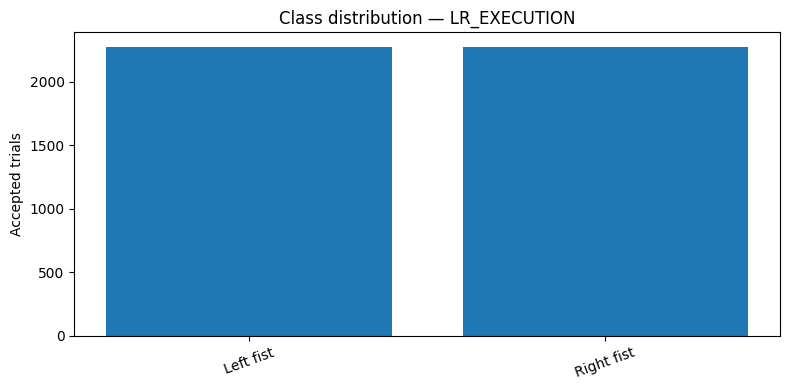

,count,mean,std,min,25%,50%,75%,max
class_name,,,,,,,,
Left fist,108.0,21.074074,3.219983,8.0,21.0,22.0,23.0,29.0
Right fist,108.0,21.037037,3.381992,8.0,21.0,22.0,23.0,29.0


In [8]:
audit = pd.Series({
    "accepted_trials": len(y),
    "rejected_events_or_files": len(rejected),
    "subjects": len(np.unique(groups)),
    "recordings": metadata[["subject", "run"]].drop_duplicates().shape[0],
    "channels": X_full.shape[1],
    "full_epoch_samples": X_full.shape[2],
    "model_samples": X_model.shape[2],
    "sampling_rate_hz": TARGET_FS,
    "mean_global_rms_uv": metadata["global_rms_uv"].mean(),
    "median_max_ptp_uv": metadata["max_ptp_uv"].median(),
})
display(audit.to_frame("value"))

class_table = (
    metadata.groupby(["class_id", "class_name"])
    .size()
    .rename("trials")
    .reset_index()
)
class_table["proportion"] = class_table["trials"] / class_table["trials"].sum()
display(class_table)

plt.figure(figsize=(8, 4))
plt.bar(class_table["class_name"], class_table["trials"])
plt.title(f"Class distribution — {TASK}")
plt.ylabel("Accepted trials")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "class_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

subject_class = pd.crosstab(metadata["subject"], metadata["class_name"])
display(subject_class.describe().T)

## 8. Leakage-safe subject-independent split

The primary split is performed by **subject ID**, not by trial. Therefore, a participant can occur in only one of train, validation, or test.

- **Training set:** model fitting, imputation, scaling, feature selection, class balancing, CSP, and functional graph estimation.
- **Validation set:** hyperparameter/model selection and selection of the baseline to beat.
- **Test set:** one final unbiased comparison.

The test set is never used to construct features, normalize data, select features, tune models, or build functional edges.


In [9]:
all_indices = np.arange(len(y))

if EVALUATION_MODE == "stratified_trials":
    train_idx, holdout_idx = train_test_split(
        all_indices,
        test_size=0.30,
        random_state=SEED,
        stratify=y,
    )
    val_idx, test_idx = train_test_split(
        holdout_idx,
        test_size=0.50,
        random_state=SEED,
        stratify=y[holdout_idx],
    )

elif EVALUATION_MODE == "subject_holdout":
    # Subject-level 70/15/15 split. Every EEGMMIDB subject contributes
    # both task classes, so grouping by subject preserves label coverage.
    first_split = GroupShuffleSplit(
        n_splits=1,
        test_size=0.30,
        random_state=SEED,
    )
    train_idx, holdout_idx = next(
        first_split.split(all_indices, y, groups=groups)
    )

    second_split = GroupShuffleSplit(
        n_splits=1,
        test_size=0.50,
        random_state=SEED + 1,
    )
    val_relative, test_relative = next(
        second_split.split(
            holdout_idx,
            y[holdout_idx],
            groups=groups[holdout_idx],
        )
    )
    val_idx = holdout_idx[val_relative]
    test_idx = holdout_idx[test_relative]

else:
    raise ValueError(
        "EVALUATION_MODE must be 'subject_holdout' or 'stratified_trials'."
    )

def split_summary_row(name, indices):
    row = {
        "split": name,
        "trials": len(indices),
        "subjects": len(np.unique(groups[indices])),
    }
    counts = np.bincount(y[indices], minlength=N_CLASSES)
    for class_id, class_name in enumerate(CLASS_NAMES):
        row[class_name] = int(counts[class_id])
    return row

split_summary = pd.DataFrame([
    split_summary_row("train", train_idx),
    split_summary_row("validation", val_idx),
    split_summary_row("test", test_idx),
])
display(split_summary)

overlaps = {
    "train_validation_subject_overlap": len(
        set(groups[train_idx]) & set(groups[val_idx])
    ),
    "train_test_subject_overlap": len(
        set(groups[train_idx]) & set(groups[test_idx])
    ),
    "validation_test_subject_overlap": len(
        set(groups[val_idx]) & set(groups[test_idx])
    ),
}
display(pd.Series(overlaps).to_frame("count"))

if EVALUATION_MODE == "subject_holdout":
    assert all(value == 0 for value in overlaps.values())
    print("PASS: no subject appears in more than one split.")
else:
    print(
        "Diagnostic mode: subjects may overlap. Do not present this as "
        "subject-independent performance."
    )

assert set(np.unique(y[train_idx])) == set(range(N_CLASSES))
assert set(np.unique(y[val_idx])) == set(range(N_CLASSES))
assert set(np.unique(y[test_idx])) == set(range(N_CLASSES))


,split,trials,subjects,Left fist,Right fist
0,train,3157,75,1577,1580
1,validation,683,16,343,340
2,test,708,17,356,352


,count
train_validation_subject_overlap,0
train_test_subject_overlap,0
validation_test_subject_overlap,0


PASS: no subject appears in more than one split.


## 9. Graph construction — proposal part A

### Nodes
Each of the 64 EEG electrodes is one graph node.

### Node features
Each node receives train-normalized temporal EEG samples plus handcrafted features: relative motor-band power, variance, RMS, line length, zero-crossing rate, and Hjorth mobility.

### Edges and edge weights
Two leakage-safe edge sources are combined:

1. **Anatomical graph:** each electrode connects to its nearest scalp neighbours. Edge weights are Gaussian functions of 3-D electrode distance.
2. **Functional graph:** each electrode connects to channels with the strongest absolute correlation, estimated from **training trials only**.

The final weighted adjacency is:

\[
A = 0.40A_{anatomical} + 0.60A_{functional}
\]

Self-loops and symmetric degree normalization are then applied. This graph is appropriate because EEG channels are not independent: nearby and functionally synchronized regions jointly represent motor activity.


In [10]:
def channel_positions(ch_names):
    montage_positions = STANDARD_MONTAGE.get_positions()["ch_pos"]
    positions = []
    missing = []
    for channel in ch_names:
        if channel in montage_positions:
            positions.append(montage_positions[channel])
        else:
            positions.append(np.array([np.nan, np.nan, np.nan]))
            missing.append(channel)
    positions = np.asarray(positions, dtype=float)

    if np.isnan(positions).any():
        valid_mean = np.nanmean(positions, axis=0)
        positions = np.where(np.isnan(positions), valid_mean, positions)

    if missing:
        print("Channels without exact montage coordinates:", missing)
    return positions

def knn_adjacency_from_positions(positions, k):
    distances = scipy.spatial.distance.cdist(positions, positions)
    np.fill_diagonal(distances, np.inf)
    adjacency = np.zeros_like(distances, dtype=np.float32)

    for node in range(len(positions)):
        neighbours = np.argsort(distances[node])[:k]
        sigma = np.median(distances[node, neighbours]) + 1e-8
        adjacency[node, neighbours] = np.exp(
            -(distances[node, neighbours] ** 2) / (2 * sigma ** 2)
        )

    adjacency = np.maximum(adjacency, adjacency.T)
    return adjacency.astype(np.float32)

def functional_adjacency_from_training(X_train, k, max_trials=1000):
    rng = np.random.default_rng(SEED)
    if len(X_train) > max_trials:
        sample_indices = rng.choice(len(X_train), size=max_trials, replace=False)
        X_train = X_train[sample_indices]

    # Concatenate time across training trials. Labels and test data are not used.
    channel_matrix = X_train.transpose(1, 0, 2).reshape(X_train.shape[1], -1)
    correlation = np.corrcoef(channel_matrix)
    correlation = np.nan_to_num(np.abs(correlation), nan=0.0)
    np.fill_diagonal(correlation, 0.0)

    adjacency = np.zeros_like(correlation, dtype=np.float32)
    for node in range(correlation.shape[0]):
        neighbours = np.argsort(correlation[node])[-k:]
        adjacency[node, neighbours] = correlation[node, neighbours]

    adjacency = np.maximum(adjacency, adjacency.T)
    return adjacency.astype(np.float32), correlation.astype(np.float32)

def normalize_adjacency(adjacency):
    adjacency = adjacency.astype(np.float32)
    adjacency = adjacency + np.eye(adjacency.shape[0], dtype=np.float32)
    degree = adjacency.sum(axis=1)
    inv_sqrt = np.power(degree + 1e-8, -0.5)
    normalized = inv_sqrt[:, None] * adjacency * inv_sqrt[None, :]
    return normalized.astype(np.float32)

positions_3d = channel_positions(channel_names)
anatomical_adjacency = knn_adjacency_from_positions(
    positions_3d,
    ANATOMICAL_K,
)
functional_adjacency, training_correlation = functional_adjacency_from_training(
    X_model[train_idx],
    FUNCTIONAL_K,
)

combined_adjacency = (
    ANATOMICAL_WEIGHT * anatomical_adjacency
    + FUNCTIONAL_WEIGHT * functional_adjacency
)
normalized_adjacency = normalize_adjacency(combined_adjacency)

np.save(OUTPUT_DIR / "anatomical_adjacency.npy", anatomical_adjacency)
np.save(OUTPUT_DIR / "functional_adjacency_train_only.npy", functional_adjacency)
np.save(OUTPUT_DIR / "combined_normalized_adjacency.npy", normalized_adjacency)

print("Adjacency shape:", normalized_adjacency.shape)
print("Non-zero anatomical edges:", int(np.count_nonzero(anatomical_adjacency) / 2))
print("Non-zero functional edges:", int(np.count_nonzero(functional_adjacency) / 2))

Adjacency shape: (64, 64)
Non-zero anatomical edges: 221
Non-zero functional edges: 327


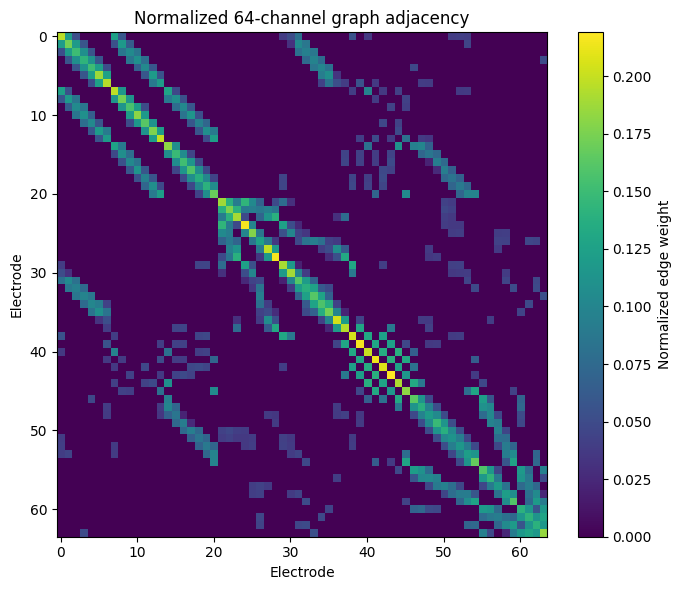

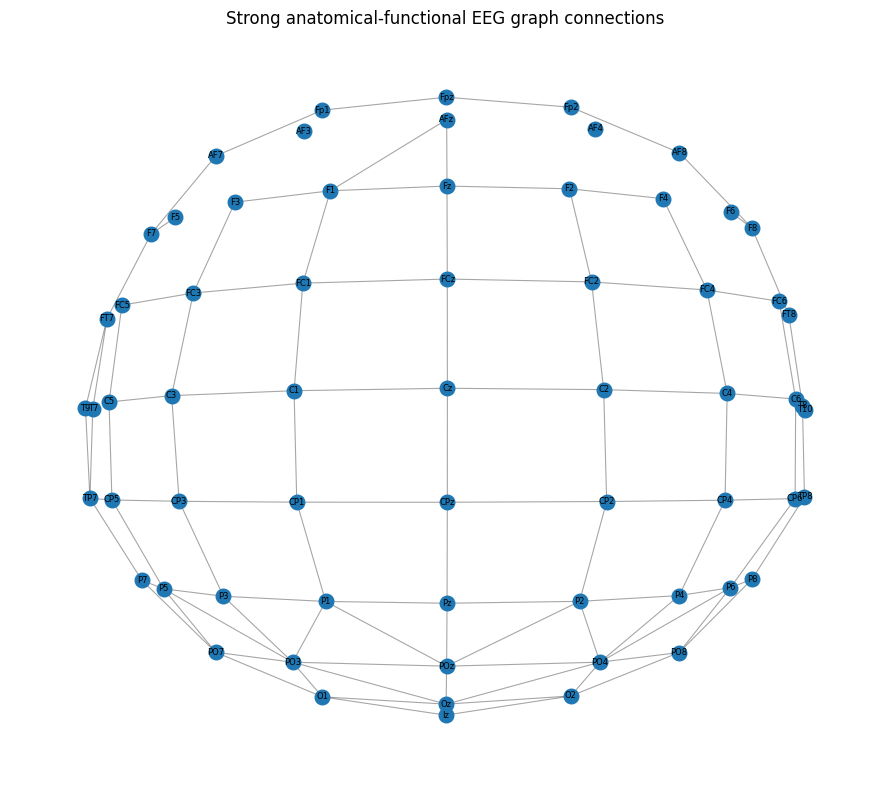

In [11]:
plt.figure(figsize=(7, 6))
plt.imshow(normalized_adjacency, aspect="auto")
plt.title("Normalized 64-channel graph adjacency")
plt.xlabel("Electrode")
plt.ylabel("Electrode")
plt.colorbar(label="Normalized edge weight")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "normalized_adjacency.png", dpi=180, bbox_inches="tight")
plt.show()

graph = nx.from_numpy_array(combined_adjacency)
positions_2d = {i: positions_3d[i, :2] for i in range(len(channel_names))}
edge_weights = np.array([graph[u][v]["weight"] for u, v in graph.edges()])
threshold = np.quantile(edge_weights, 0.70) if len(edge_weights) else 0
strong_graph = nx.Graph()
strong_graph.add_nodes_from(graph.nodes())
strong_graph.add_edges_from(
    (u, v, data)
    for u, v, data in graph.edges(data=True)
    if data["weight"] >= threshold
)

plt.figure(figsize=(9, 8))
nx.draw_networkx_nodes(strong_graph, positions_2d, node_size=110)
nx.draw_networkx_edges(strong_graph, positions_2d, alpha=0.35, width=0.8)
nx.draw_networkx_labels(
    strong_graph,
    positions_2d,
    labels={i: channel_names[i] for i in strong_graph.nodes()},
    font_size=6,
)
plt.title("Strong anatomical-functional EEG graph connections")
plt.axis("off")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "brain_graph.png", dpi=200, bbox_inches="tight")
plt.show()

## 10. Handcrafted spectral and temporal node features

In [12]:
SPECTRAL_BANDS = {
    "mu_8_12": (8.0, 12.0),
    "low_beta_12_16": (12.0, 16.0),
    "mid_beta_16_20": (16.0, 20.0),
    "high_beta_20_24": (20.0, 24.0),
    "upper_beta_24_30": (24.0, 30.0),
}

def vectorized_node_features(X, sfreq):
    frequencies = np.fft.rfftfreq(X.shape[-1], d=1.0 / sfreq)
    spectrum = np.fft.rfft(X, axis=-1)
    power = (np.abs(spectrum) ** 2).astype(np.float32)

    total_mask = (frequencies >= LOW_FREQ) & (frequencies <= HIGH_FREQ)
    total_power = power[..., total_mask].sum(axis=-1) + 1e-8

    features = []
    feature_names = []

    for band_name, (low, high) in SPECTRAL_BANDS.items():
        mask = (frequencies >= low) & (frequencies < high)
        band_power = power[..., mask].sum(axis=-1)
        relative_power = band_power / total_power
        features.append(np.log10(relative_power + 1e-8))
        feature_names.append(f"logrel_{band_name}")

    variance = np.var(X, axis=-1) + 1e-8
    rms = np.sqrt(np.mean(X ** 2, axis=-1) + 1e-8)
    line_length = np.mean(np.abs(np.diff(X, axis=-1)), axis=-1)
    zero_crossing = np.mean(
        np.diff(np.signbit(X), axis=-1) != 0,
        axis=-1,
    )

    first_diff = np.diff(X, axis=-1)
    mobility = np.sqrt(
        (np.var(first_diff, axis=-1) + 1e-8) / variance
    )

    for values, name in [
        (np.log10(variance), "log_variance"),
        (np.log10(rms + 1e-8), "log_rms"),
        (np.log10(line_length + 1e-8), "log_line_length"),
        (zero_crossing, "zero_crossing_rate"),
        (mobility, "hjorth_mobility"),
    ]:
        features.append(values)
        feature_names.append(name)

    node_features = np.stack(features, axis=-1).astype(np.float32)
    node_features = np.nan_to_num(node_features, nan=0.0, posinf=0.0, neginf=0.0)
    return node_features, feature_names

NODE_FEATURE_CACHE = CACHE_DIR / cache_name.replace(".npz", "_node_features.npz")

if NODE_FEATURE_CACHE.exists():
    feature_cache = np.load(NODE_FEATURE_CACHE, allow_pickle=True)
    node_features = feature_cache["node_features"].astype(np.float32)
    NODE_FEATURE_NAMES = feature_cache["feature_names"].tolist()
else:
    node_features, NODE_FEATURE_NAMES = vectorized_node_features(
        X_model,
        TARGET_FS,
    )
    np.savez_compressed(
        NODE_FEATURE_CACHE,
        node_features=node_features,
        feature_names=np.asarray(NODE_FEATURE_NAMES),
    )

print("Node feature tensor:", node_features.shape)
print("Node features:", NODE_FEATURE_NAMES)

Node feature tensor: (4548, 64, 10)
Node features: ['logrel_mu_8_12', 'logrel_low_beta_12_16', 'logrel_mid_beta_16_20', 'logrel_high_beta_20_24', 'logrel_upper_beta_24_30', 'log_variance', 'log_rms', 'log_line_length', 'zero_crossing_rate', 'hjorth_mobility']


## 11. Baseline-normalized ERD/ERS analysis

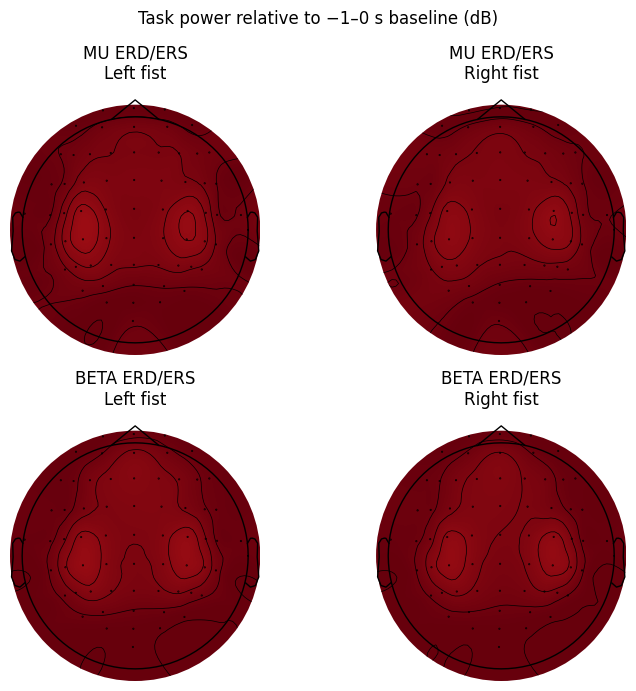

,band,class_name,mean_db_change,median_db_change
0,mu,Left fist,9.566019,9.570261
1,mu,Right fist,9.652224,9.668324
2,beta,Left fist,8.726689,8.783773
3,beta,Right fist,8.796575,8.847063


In [13]:
def segment_relative_band_power(X_segment, sfreq, low, high):
    frequencies = np.fft.rfftfreq(X_segment.shape[-1], d=1.0 / sfreq)
    spectrum = np.fft.rfft(X_segment, axis=-1)
    power = np.abs(spectrum) ** 2
    band_mask = (frequencies >= low) & (frequencies < high)
    return power[..., band_mask].sum(axis=-1) + 1e-8

baseline_start = int(round((-1.0 - FULL_TMIN) * TARGET_FS))
baseline_stop = int(round((0.0 - FULL_TMIN) * TARGET_FS))
task_start = int(round((0.5 - FULL_TMIN) * TARGET_FS))
task_stop = int(round((3.5 - FULL_TMIN) * TARGET_FS))

baseline_signal = X_full[:, :, baseline_start:baseline_stop]
task_signal = X_full[:, :, task_start:task_stop]

erd_ers = {}
for band_name, (low, high) in {
    "mu": (8.0, 12.0),
    "beta": (13.0, 30.0),
}.items():
    baseline_power = segment_relative_band_power(
        baseline_signal, TARGET_FS, low, high
    )
    task_power = segment_relative_band_power(
        task_signal, TARGET_FS, low, high
    )
    # dB task-to-baseline change: negative = ERD, positive = ERS.
    erd_ers[band_name] = (
        10.0 * np.log10(task_power / baseline_power)
    ).astype(np.float32)

info = mne.create_info(
    ch_names=channel_names,
    sfreq=TARGET_FS,
    ch_types=["eeg"] * len(channel_names),
)
info.set_montage(STANDARD_MONTAGE, on_missing="ignore")

fig, axes = plt.subplots(
    2,
    N_CLASSES,
    figsize=(4 * N_CLASSES, 7),
    squeeze=False,
)
for band_row, band_name in enumerate(["mu", "beta"]):
    class_values = [
        erd_ers[band_name][y == class_id].mean(axis=0)
        for class_id in range(N_CLASSES)
    ]
    all_values = np.concatenate(class_values)
    vmax = np.nanpercentile(np.abs(all_values), 95)
    vmax = max(float(vmax), 0.1)

    for class_id, class_name in enumerate(CLASS_NAMES):
        mne.viz.plot_topomap(
            class_values[class_id],
            info,
            axes=axes[band_row, class_id],
            show=False,
            contours=4,
            vlim=(-vmax, vmax),
        )
        axes[band_row, class_id].set_title(
            f"{band_name.upper()} ERD/ERS\n{class_name}"
        )

plt.suptitle("Task power relative to −1–0 s baseline (dB)")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "erd_ers_topomaps.png", dpi=200, bbox_inches="tight")
plt.show()

erd_summary_rows = []
for band_name, values in erd_ers.items():
    for class_id, class_name in enumerate(CLASS_NAMES):
        erd_summary_rows.append({
            "band": band_name,
            "class_name": class_name,
            "mean_db_change": float(values[y == class_id].mean()),
            "median_db_change": float(np.median(values[y == class_id])),
        })
display(pd.DataFrame(erd_summary_rows))

## 12. PyTorch dataset and data augmentation

In [14]:
# All normalization statistics are fitted on TRAINING data only.
channel_mean = X_model[train_idx].mean(axis=(0, 2)).astype(np.float32)
channel_std = X_model[train_idx].std(axis=(0, 2)).astype(np.float32)
channel_std = np.maximum(channel_std, 1e-3)

feature_mean = node_features[train_idx].mean(axis=(0, 1)).astype(np.float32)
feature_std = node_features[train_idx].std(axis=(0, 1)).astype(np.float32)
feature_std = np.maximum(feature_std, 1e-4)

class EEGGraphDataset(Dataset):
    def __init__(self, indices, augment=False):
        self.indices = np.asarray(indices)
        self.augment = augment

    def __len__(self):
        return len(self.indices)

    def _augment_signal(self, signal):
        # Mild augmentation only. The previous notebook used stronger masking,
        # which can make a 20-epoch model underfit.
        if np.random.rand() < 0.45:
            signal = signal * np.random.uniform(0.95, 1.05)

        if np.random.rand() < 0.35:
            signal = signal + np.random.normal(
                0.0, 0.012, size=signal.shape
            ).astype(np.float32)

        if np.random.rand() < 0.25:
            shift = np.random.randint(-5, 6)
            signal = np.roll(signal, shift=shift, axis=-1)

        if np.random.rand() < 0.15:
            mask_length = np.random.randint(4, 13)
            mask_start = np.random.randint(
                0, signal.shape[-1] - mask_length + 1
            )
            signal[:, mask_start:mask_start + mask_length] = 0.0

        return signal

    def __getitem__(self, item):
        index = int(self.indices[item])

        signal = X_model[index].copy()
        signal = (signal - channel_mean[:, None]) / channel_std[:, None]

        spectral = node_features[index].copy()
        spectral = (
            spectral - feature_mean[None, :]
        ) / feature_std[None, :]

        if self.augment:
            signal = self._augment_signal(signal)

        return (
            torch.from_numpy(signal.astype(np.float32)),
            torch.from_numpy(spectral.astype(np.float32)),
            torch.tensor(y[index], dtype=torch.long),
            torch.tensor(index, dtype=torch.long),
        )

train_dataset = EEGGraphDataset(train_idx, augment=True)
train_eval_dataset = EEGGraphDataset(train_idx, augment=False)
val_dataset = EEGGraphDataset(val_idx, augment=False)
test_dataset = EEGGraphDataset(test_idx, augment=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)
train_eval_loader = DataLoader(
    train_eval_dataset,
    batch_size=BATCH_SIZE * 2,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE * 2,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE * 2,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

batch_signal, batch_features, batch_labels, batch_indices = next(
    iter(train_loader)
)
print("Signal batch:", batch_signal.shape)
print("Node-feature batch:", batch_features.shape)
print("Label batch:", batch_labels.shape)


Signal batch: torch.Size([64, 64, 400])
Node-feature batch: torch.Size([64, 64, 10])
Label batch: torch.Size([64])


## 13. Leakage-safe baseline feature preparation

This section implements the required preprocessing for the classical baselines:

- integer label encoding from the task definition;
- median missing-value imputation;
- standardization;
- univariate feature selection;
- train-only random oversampling for algorithms without class weights;
- no use of validation or test data while fitting preprocessing.

The baseline feature vector contains the flattened node features plus left-right homologous electrode asymmetry features. Asymmetry is useful for left-versus-right motor decoding, while remaining physiologically interpretable.


In [15]:
def homologous_channel_pairs(ch_names):
    lookup = {name.lower(): i for i, name in enumerate(ch_names)}
    candidate_pairs = [
        ("FC5", "FC6"), ("FC3", "FC4"), ("FC1", "FC2"),
        ("C5", "C6"), ("C3", "C4"), ("C1", "C2"),
        ("CP5", "CP6"), ("CP3", "CP4"), ("CP1", "CP2"),
        ("F3", "F4"), ("F7", "F8"),
        ("P3", "P4"), ("P7", "P8"),
    ]
    pairs = []
    for left, right in candidate_pairs:
        if left.lower() in lookup and right.lower() in lookup:
            pairs.append((lookup[left.lower()], lookup[right.lower()], left, right))
    return pairs

ASYMMETRY_PAIRS = homologous_channel_pairs(channel_names)

flat_node_features = node_features.reshape(len(node_features), -1)
asymmetry_parts = []
asymmetry_names = []

for left_idx, right_idx, left_name, right_name in ASYMMETRY_PAIRS:
    difference = (
        node_features[:, left_idx, :] - node_features[:, right_idx, :]
    )
    asymmetry_parts.append(difference)
    asymmetry_names.extend(
        [
            f"{left_name}_minus_{right_name}_{feature_name}"
            for feature_name in NODE_FEATURE_NAMES
        ]
    )

if asymmetry_parts:
    asymmetry_features = np.concatenate(asymmetry_parts, axis=1)
    baseline_features_raw = np.concatenate(
        [flat_node_features, asymmetry_features], axis=1
    )
else:
    asymmetry_features = np.empty((len(y), 0), dtype=np.float32)
    baseline_features_raw = flat_node_features

baseline_features_raw = np.nan_to_num(
    baseline_features_raw,
    nan=np.nan,
    posinf=np.nan,
    neginf=np.nan,
).astype(np.float32)

print("Baseline raw feature matrix:", baseline_features_raw.shape)
print("Homologous pairs:", len(ASYMMETRY_PAIRS))

# Fit every transform on training data only.
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()
selector = SelectKBest(
    score_func=f_classif,
    k=min(SELECT_K_FEATURES, baseline_features_raw.shape[1]),
)

X_train_base = imputer.fit_transform(baseline_features_raw[train_idx])
X_train_base = scaler.fit_transform(X_train_base)
X_train_base = selector.fit_transform(X_train_base, y[train_idx])

X_val_base = selector.transform(
    scaler.transform(
        imputer.transform(baseline_features_raw[val_idx])
    )
)
X_test_base = selector.transform(
    scaler.transform(
        imputer.transform(baseline_features_raw[test_idx])
    )
)

y_train = y[train_idx]
y_val = y[val_idx]
y_test = y[test_idx]

def random_oversample(X, labels, seed=42):
    rng = np.random.default_rng(seed)
    classes, counts = np.unique(labels, return_counts=True)
    target_count = counts.max()
    sampled_indices = []
    for class_id, count in zip(classes, counts):
        class_indices = np.flatnonzero(labels == class_id)
        if count < target_count:
            extra = rng.choice(
                class_indices,
                size=target_count - count,
                replace=True,
            )
            class_indices = np.concatenate([class_indices, extra])
        sampled_indices.append(class_indices)
    sampled_indices = np.concatenate(sampled_indices)
    rng.shuffle(sampled_indices)
    return X[sampled_indices], labels[sampled_indices]

X_train_balanced, y_train_balanced = random_oversample(
    X_train_base, y_train, seed=SEED
)

print("Selected baseline features:", X_train_base.shape[1])
print("Original train counts:", Counter(y_train))
print("Oversampled train counts:", Counter(y_train_balanced))

joblib.dump(
    {
        "imputer": imputer,
        "scaler": scaler,
        "selector": selector,
        "asymmetry_pairs": ASYMMETRY_PAIRS,
        "node_feature_names": NODE_FEATURE_NAMES,
    },
    MODEL_DIR / "baseline_preprocessing.joblib",
)


Baseline raw feature matrix: (4548, 770)
Homologous pairs: 13
Selected baseline features: 384
Original train counts: Counter({np.int64(1): 1580, np.int64(0): 1577})
Oversampled train counts: Counter({np.int64(0): 1580, np.int64(1): 1580})


['/kaggle/working/eeg_task2_output/models/baseline_preprocessing.joblib']

## 14. Full evaluation metric set

For every model, the notebook reports:

- accuracy;
- balanced accuracy;
- macro precision;
- macro recall;
- macro F1;
- weighted F1;
- Matthews correlation coefficient;
- Cohen's kappa;
- ROC-AUC;
- log loss;
- training time;
- test inference time.

The **baseline to beat** is selected only by validation macro F1. Test performance does not influence model selection.


In [16]:
def safe_predict_proba(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        if scores.ndim == 1:
            scores = np.column_stack([-scores, scores])
        scores = scores - scores.max(axis=1, keepdims=True)
        exp_scores = np.exp(scores)
        return exp_scores / exp_scores.sum(axis=1, keepdims=True)
    predictions = model.predict(X)
    probabilities = np.zeros((len(predictions), N_CLASSES), dtype=float)
    probabilities[np.arange(len(predictions)), predictions] = 1.0
    return probabilities

def metric_row(
    model_name,
    split_name,
    y_true,
    probabilities,
    training_seconds=np.nan,
    inference_seconds=np.nan,
    model_family="baseline",
):
    probabilities = np.asarray(probabilities)
    predictions = probabilities.argmax(axis=1)

    row = {
        "model": model_name,
        "family": model_family,
        "split": split_name,
        "accuracy": accuracy_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "precision_macro": precision_score(
            y_true, predictions, average="macro", zero_division=0
        ),
        "recall_macro": recall_score(
            y_true, predictions, average="macro", zero_division=0
        ),
        "f1_macro": f1_score(
            y_true, predictions, average="macro", zero_division=0
        ),
        "f1_weighted": f1_score(
            y_true, predictions, average="weighted", zero_division=0
        ),
        "mcc": matthews_corrcoef(y_true, predictions),
        "cohen_kappa": cohen_kappa_score(y_true, predictions),
        "log_loss": log_loss(
            y_true,
            np.clip(probabilities, 1e-7, 1 - 1e-7),
            labels=np.arange(N_CLASSES),
        ),
        "training_seconds": training_seconds,
        "inference_seconds": inference_seconds,
    }

    try:
        if N_CLASSES == 2:
            row["roc_auc"] = roc_auc_score(y_true, probabilities[:, 1])
        else:
            row["roc_auc"] = roc_auc_score(
                y_true,
                probabilities,
                multi_class="ovr",
                average="macro",
            )
    except Exception:
        row["roc_auc"] = np.nan

    return row

baseline_results = []
baseline_probabilities = {}
baseline_models = {}


## 15. Classical baselines

The benchmark includes Logistic Regression, SVM, k-NN, Decision Tree, Random Forest, Gradient Boosting, Extra Trees, and MLP. XGBoost is added automatically when the package is available.

Models with a `class_weight` parameter use balanced weights. k-NN, Gradient Boosting, and MLP use the train-only oversampled matrix.


In [17]:
baseline_specs = {
    "Logistic Regression": (
        LogisticRegression(
            C=1.0,
            max_iter=3000,
            class_weight="balanced",
            solver="liblinear" if N_CLASSES == 2 else "lbfgs",
            random_state=SEED,
        ),
        False,
    ),
    "RBF SVM": (
        SVC(
            C=3.0,
            gamma="scale",
            kernel="rbf",
            class_weight="balanced",
            probability=True,
            random_state=SEED,
        ),
        False,
    ),
    "k-NN": (
        KNeighborsClassifier(
            n_neighbors=9,
            weights="distance",
            metric="minkowski",
            p=2,
            n_jobs=-1,
        ),
        True,
    ),
    "Decision Tree": (
        DecisionTreeClassifier(
            max_depth=12,
            min_samples_leaf=4,
            class_weight="balanced",
            random_state=SEED,
        ),
        False,
    ),
    "Random Forest": (
        RandomForestClassifier(
            n_estimators=500 if not QUICK_RUN else 120,
            max_features="sqrt",
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=SEED,
        ),
        False,
    ),
    "Gradient Boosting": (
        GradientBoostingClassifier(
            n_estimators=180 if not QUICK_RUN else 60,
            learning_rate=0.04,
            max_depth=3,
            subsample=0.85,
            random_state=SEED,
        ),
        True,
    ),
    "Extra Trees": (
        ExtraTreesClassifier(
            n_estimators=600 if not QUICK_RUN else 150,
            max_features=0.70,
            min_samples_leaf=1,
            class_weight="balanced",
            n_jobs=-1,
            random_state=SEED,
        ),
        False,
    ),
    "MLP": (
        MLPClassifier(
            hidden_layer_sizes=(256, 64),
            activation="relu",
            alpha=3e-4,
            batch_size=64,
            learning_rate_init=8e-4,
            max_iter=20,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=15,
            random_state=SEED,
        ),
        True,
    ),
}

if RUN_XGBOOST_IF_AVAILABLE and importlib.util.find_spec("xgboost") is not None:
    from xgboost import XGBClassifier

    baseline_specs["XGBoost"] = (
        XGBClassifier(
            n_estimators=350 if not QUICK_RUN else 100,
            max_depth=5,
            learning_rate=0.035,
            subsample=0.85,
            colsample_bytree=0.80,
            reg_alpha=0.05,
            reg_lambda=1.0,
            objective=(
                "binary:logistic"
                if N_CLASSES == 2
                else "multi:softprob"
            ),
            eval_metric="logloss",
            n_jobs=-1,
            random_state=SEED,
        ),
        True,
    )
else:
    print("XGBoost not available; continuing with the other baselines.")

for model_name, (model, use_oversampled_train) in baseline_specs.items():
    print(f"Training {model_name}...")
    fit_X = X_train_balanced if use_oversampled_train else X_train_base
    fit_y = y_train_balanced if use_oversampled_train else y_train

    start = time.perf_counter()
    model.fit(fit_X, fit_y)
    training_seconds = time.perf_counter() - start

    val_start = time.perf_counter()
    val_probs = safe_predict_proba(model, X_val_base)
    val_inference_seconds = time.perf_counter() - val_start

    test_start = time.perf_counter()
    test_probs = safe_predict_proba(model, X_test_base)
    test_inference_seconds = time.perf_counter() - test_start

    baseline_results.append(
        metric_row(
            model_name,
            "validation",
            y_val,
            val_probs,
            training_seconds=training_seconds,
            inference_seconds=val_inference_seconds,
        )
    )
    baseline_results.append(
        metric_row(
            model_name,
            "test",
            y_test,
            test_probs,
            training_seconds=training_seconds,
            inference_seconds=test_inference_seconds,
        )
    )

    baseline_probabilities[model_name] = {
        "validation": val_probs,
        "test": test_probs,
    }
    baseline_models[model_name] = model
    joblib.dump(
        model,
        MODEL_DIR / (
            re.sub(r"[^a-zA-Z0-9]+", "_", model_name).strip("_").lower()
            + ".joblib"
        ),
    )

baseline_results_frame = pd.DataFrame(baseline_results)
display(
    baseline_results_frame[
        baseline_results_frame["split"] == "validation"
    ].sort_values("f1_macro", ascending=False)
)


Training Logistic Regression...
Training RBF SVM...
Training k-NN...
Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...
Training Extra Trees...
Training MLP...
Training XGBoost...


,model,family,split,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,mcc,cohen_kappa,log_loss,training_seconds,inference_seconds,roc_auc
0,Logistic Regression,baseline,validation,0.660322,0.660431,0.660804,0.660431,0.660158,0.660125,0.321235,0.320788,0.730162,0.911983,0.001514,0.696999
14,MLP,baseline,validation,0.653001,0.653091,0.653328,0.653091,0.652894,0.652868,0.306419,0.306123,0.872576,2.328184,0.002337,0.698945
16,XGBoost,baseline,validation,0.644217,0.644332,0.644709,0.644332,0.644021,0.643985,0.289041,0.288594,0.683638,17.489722,0.011024,0.688853
12,Extra Trees,baseline,validation,0.641288,0.641275,0.641280,0.641275,0.641276,0.641285,0.282555,0.282554,0.646941,25.791435,0.227672,0.679009
10,Gradient Boosting,baseline,validation,0.636896,0.636863,0.636896,0.636863,0.636858,0.636874,0.273759,0.273741,0.637923,92.521166,0.004162,0.691494
8,Random Forest,baseline,validation,0.632504,0.632477,0.632498,0.632477,0.632475,0.632489,0.264975,0.264965,0.641628,13.204410,0.176707,0.681418
2,RBF SVM,baseline,validation,0.632504,0.632786,0.634973,0.632786,0.631109,0.631009,0.267750,0.265418,0.696778,9.163241,0.632356,0.686872
4,k-NN,baseline,validation,0.585652,0.586100,0.589819,0.586100,0.581503,0.581320,0.175879,0.172043,0.754339,0.001517,0.196398,0.650171
6,Decision Tree,baseline,validation,0.578331,0.578310,0.578317,0.578310,0.578308,0.578322,0.156627,0.156624,3.714917,1.913015,0.000554,0.581427


## 16. Motor-area CSP-LDA baseline

CSP learns discriminative spatial filters from the training EEG only, and LDA performs classification on the resulting log-variance features. This is a strong domain-specific EEG baseline and is included separately from the general machine-learning models.


In [18]:
MOTOR_CHANNEL_CANDIDATES = [
    "FC5", "FC3", "FC1", "FCz", "FC2", "FC4", "FC6",
    "C5", "C3", "C1", "Cz", "C2", "C4", "C6",
    "CP5", "CP3", "CP1", "CPz", "CP2", "CP4", "CP6",
]
channel_lookup = {name.lower(): index for index, name in enumerate(channel_names)}
motor_indices = [
    channel_lookup[name.lower()]
    for name in MOTOR_CHANNEL_CANDIDATES
    if name.lower() in channel_lookup
]
if len(motor_indices) < 8:
    motor_indices = list(range(len(channel_names)))

if RUN_CSP_LDA:
    try:
        X_csp = X_model[:, motor_indices, :].astype(np.float64)
        csp_pipeline = make_pipeline(
            CSP(
                n_components=min(16, max(6, len(motor_indices) // 2)),
                reg="ledoit_wolf",
                log=True,
                norm_trace=False,
                cov_est="epoch",
            ),
            LinearDiscriminantAnalysis(
                solver="lsqr",
                shrinkage="auto",
            ),
        )

        start = time.perf_counter()
        csp_pipeline.fit(X_csp[train_idx], y_train)
        csp_training_seconds = time.perf_counter() - start

        start = time.perf_counter()
        csp_val_probs = csp_pipeline.predict_proba(X_csp[val_idx])
        csp_val_inference = time.perf_counter() - start

        start = time.perf_counter()
        csp_test_probs = csp_pipeline.predict_proba(X_csp[test_idx])
        csp_test_inference = time.perf_counter() - start

        baseline_results.extend([
            metric_row(
                "Motor-area CSP-LDA",
                "validation",
                y_val,
                csp_val_probs,
                csp_training_seconds,
                csp_val_inference,
            ),
            metric_row(
                "Motor-area CSP-LDA",
                "test",
                y_test,
                csp_test_probs,
                csp_training_seconds,
                csp_test_inference,
            ),
        ])
        baseline_probabilities["Motor-area CSP-LDA"] = {
            "validation": csp_val_probs,
            "test": csp_test_probs,
        }
        baseline_models["Motor-area CSP-LDA"] = csp_pipeline
        joblib.dump(csp_pipeline, MODEL_DIR / "motor_area_csp_lda.joblib")
        del X_csp
    except Exception as error:
        print("CSP-LDA skipped:", repr(error))

baseline_results_frame = pd.DataFrame(baseline_results)

validation_baselines = baseline_results_frame[
    baseline_results_frame["split"] == "validation"
].sort_values(
    ["f1_macro", "balanced_accuracy", "accuracy"],
    ascending=False,
)

BASELINE_TO_BEAT = validation_baselines.iloc[0]["model"]
BASELINE_TO_BEAT_VAL_F1 = float(validation_baselines.iloc[0]["f1_macro"])

print("Baseline to beat:", BASELINE_TO_BEAT)
print("Validation macro F1:", f"{BASELINE_TO_BEAT_VAL_F1:.4f}")
display(validation_baselines)

baseline_results_frame.to_csv(
    OUTPUT_DIR / "baseline_full_metrics.csv",
    index=False,
)


Baseline to beat: Logistic Regression
Validation macro F1: 0.6602


,model,family,split,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,mcc,cohen_kappa,log_loss,training_seconds,inference_seconds,roc_auc
0,Logistic Regression,baseline,validation,0.660322,0.660431,0.660804,0.660431,0.660158,0.660125,0.321235,0.320788,0.730162,0.911983,0.001514,0.696999
14,MLP,baseline,validation,0.653001,0.653091,0.653328,0.653091,0.652894,0.652868,0.306419,0.306123,0.872576,2.328184,0.002337,0.698945
16,XGBoost,baseline,validation,0.644217,0.644332,0.644709,0.644332,0.644021,0.643985,0.289041,0.288594,0.683638,17.489722,0.011024,0.688853
18,Motor-area CSP-LDA,baseline,validation,0.642753,0.642939,0.643938,0.642939,0.642193,0.642131,0.286875,0.285767,0.636699,13.859758,0.027595,0.693123
12,Extra Trees,baseline,validation,0.641288,0.641275,0.641280,0.641275,0.641276,0.641285,0.282555,0.282554,0.646941,25.791435,0.227672,0.679009
10,Gradient Boosting,baseline,validation,0.636896,0.636863,0.636896,0.636863,0.636858,0.636874,0.273759,0.273741,0.637923,92.521166,0.004162,0.691494
8,Random Forest,baseline,validation,0.632504,0.632477,0.632498,0.632477,0.632475,0.632489,0.264975,0.264965,0.641628,13.204410,0.176707,0.681418
2,RBF SVM,baseline,validation,0.632504,0.632786,0.634973,0.632786,0.631109,0.631009,0.267750,0.265418,0.696778,9.163241,0.632356,0.686872
4,k-NN,baseline,validation,0.585652,0.586100,0.589819,0.586100,0.581503,0.581320,0.175879,0.172043,0.754339,0.001517,0.196398,0.650171
6,Decision Tree,baseline,validation,0.578331,0.578310,0.578317,0.578310,0.578308,0.578322,0.156627,0.156624,3.714917,1.913015,0.000554,0.581427


## 17. Compact 1D-CNN baseline

The 1D-CNN sees the normalized 64-channel EEG sequence but does not use an explicit graph. It tests whether graph-based spatial propagation adds value beyond temporal convolution.


In [19]:
class CompactEEG1DCNN(nn.Module):
    def __init__(self, n_channels, n_classes, dropout=0.20):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(n_channels, 96, kernel_size=15, padding=7, bias=False),
            nn.BatchNorm1d(96),
            nn.GELU(),
            nn.MaxPool1d(2),
            nn.Conv1d(96, 128, kernel_size=9, padding=4, groups=4, bias=False),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.MaxPool1d(2),
            nn.Conv1d(128, 160, kernel_size=7, padding=3, groups=4, bias=False),
            nn.BatchNorm1d(160),
            nn.GELU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(160, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )

    def forward(self, signal, node_features=None):
        return self.classifier(self.features(signal))


## 18. Hybrid ST-GNN proposal — part B and C

### Architecture
`EEG input → temporal convolution → graph propagation → residual temporal filtering → electrode attention/readout`

A second branch transforms handcrafted node features, propagates them across the same graph, and applies attentive pooling. The raw-signal and node-feature summaries are fused for classification.

### Why this should reduce underfitting
Compared with the earlier notebook, this version:

- uses the motor-focused 8–30 Hz band;
- retains the full 0–4 s task period;
- reduces overly strong augmentation;
- lowers dropout and weight decay;
- uses a higher initial learning rate with One-Cycle scheduling;
- uses residual graph-temporal blocks;
- selects the best checkpoint by validation macro F1;
- limits training to 20 epochs.


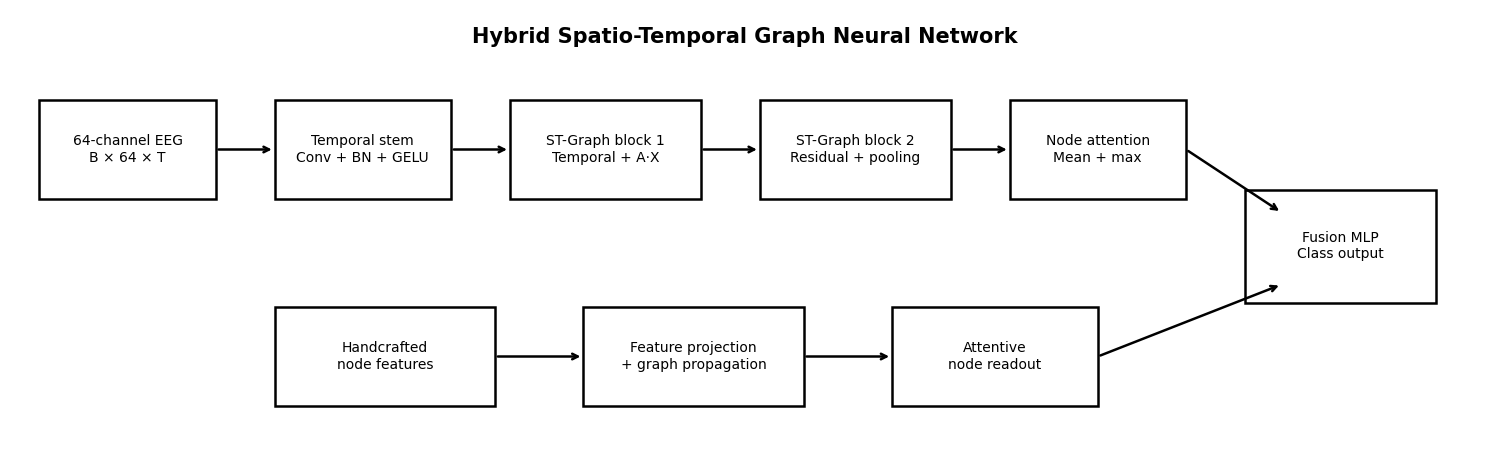

In [20]:
# Architecture diagram for the presentation.
fig, ax = plt.subplots(figsize=(15, 4.8))
ax.axis("off")

boxes = [
    (0.02, 0.58, 0.12, 0.22, "64-channel EEG\nB × 64 × T"),
    (0.18, 0.58, 0.12, 0.22, "Temporal stem\nConv + BN + GELU"),
    (0.34, 0.58, 0.13, 0.22, "ST-Graph block 1\nTemporal + A·X"),
    (0.51, 0.58, 0.13, 0.22, "ST-Graph block 2\nResidual + pooling"),
    (0.68, 0.58, 0.12, 0.22, "Node attention\nMean + max"),
    (0.18, 0.12, 0.15, 0.22, "Handcrafted\nnode features"),
    (0.39, 0.12, 0.15, 0.22, "Feature projection\n+ graph propagation"),
    (0.60, 0.12, 0.14, 0.22, "Attentive\nnode readout"),
    (0.84, 0.35, 0.13, 0.25, "Fusion MLP\nClass output"),
]

for x, y0, w, h, label in boxes:
    rectangle = plt.Rectangle((x, y0), w, h, fill=False, linewidth=1.8)
    ax.add_patch(rectangle)
    ax.text(x + w / 2, y0 + h / 2, label, ha="center", va="center", fontsize=10)

arrows = [
    ((0.14, 0.69), (0.18, 0.69)),
    ((0.30, 0.69), (0.34, 0.69)),
    ((0.47, 0.69), (0.51, 0.69)),
    ((0.64, 0.69), (0.68, 0.69)),
    ((0.80, 0.69), (0.865, 0.55)),
    ((0.33, 0.23), (0.39, 0.23)),
    ((0.54, 0.23), (0.60, 0.23)),
    ((0.74, 0.23), (0.865, 0.39)),
]
for start, end in arrows:
    ax.annotate(
        "",
        xy=end,
        xytext=start,
        arrowprops=dict(arrowstyle="->", linewidth=1.8),
    )

ax.text(
    0.50,
    0.94,
    "Hybrid Spatio-Temporal Graph Neural Network",
    ha="center",
    va="center",
    fontsize=15,
    fontweight="bold",
)
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "stgnn_architecture_diagram.png",
    dpi=220,
    bbox_inches="tight",
)
plt.show()


In [21]:
class STGraphBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dropout):
        super().__init__()
        padding = kernel_size // 2

        self.temporal = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=(1, kernel_size),
                padding=(0, padding),
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.GELU(),
        )

        self.graph_mix = nn.Sequential(
            nn.Conv2d(out_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.GELU(),
        )

        self.refine = nn.Sequential(
            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=(1, 7),
                padding=(0, 3),
                groups=out_channels,
                bias=False,
            ),
            nn.Conv2d(out_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
        )

        self.residual = (
            nn.Identity()
            if in_channels == out_channels
            else nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        )
        self.pool = nn.AvgPool2d((1, 2))
        self.dropout = nn.Dropout(dropout)
        self.graph_gate = nn.Parameter(torch.tensor(0.70))

    def forward(self, x, adjacency):
        residual = self.residual(x)
        temporal = self.temporal(x)

        graph_signal = torch.einsum(
            "nm,bcmt->bcnt", adjacency, temporal
        )
        gate = torch.sigmoid(self.graph_gate)
        mixed = gate * graph_signal + (1.0 - gate) * temporal
        mixed = self.graph_mix(mixed)
        mixed = self.refine(mixed)

        output = F.gelu(mixed + residual)
        output = self.pool(output)
        return self.dropout(output)


class HybridSTGNN(nn.Module):
    def __init__(
        self,
        adjacency,
        n_node_features,
        n_classes,
        dropout=0.20,
    ):
        super().__init__()
        self.register_buffer(
            "adjacency",
            torch.tensor(adjacency, dtype=torch.float32),
        )

        self.block1 = STGraphBlock(1, 48, 15, dropout * 0.6)
        self.block2 = STGraphBlock(48, 80, 11, dropout)
        self.block3 = STGraphBlock(80, 112, 7, dropout)

        self.raw_attention = nn.Conv1d(112, 1, kernel_size=1)

        self.feature_projection = nn.Sequential(
            nn.Linear(n_node_features, 64),
            nn.LayerNorm(64),
            nn.GELU(),
        )
        self.feature_graph = nn.Sequential(
            nn.Linear(64, 64),
            nn.LayerNorm(64),
            nn.GELU(),
        )
        self.feature_attention = nn.Linear(64, 1)

        fusion_size = (112 * 2) + (64 * 2)
        self.classifier = nn.Sequential(
            nn.Linear(fusion_size, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 96),
            nn.GELU(),
            nn.Dropout(dropout * 0.75),
            nn.Linear(96, n_classes),
        )

    def forward(self, signal, node_features):
        raw = signal.unsqueeze(1)
        raw = self.block1(raw, self.adjacency)
        raw = self.block2(raw, self.adjacency)
        raw = self.block3(raw, self.adjacency)

        raw_nodes = raw.mean(dim=-1)
        raw_weights = torch.softmax(
            self.raw_attention(raw_nodes).squeeze(1),
            dim=-1,
        )
        raw_attention_pool = torch.sum(
            raw_nodes * raw_weights.unsqueeze(1),
            dim=-1,
        )
        raw_max_pool = raw_nodes.max(dim=-1).values

        features = self.feature_projection(node_features)
        features = torch.einsum(
            "nm,bmf->bnf", self.adjacency, features
        )
        features = self.feature_graph(features)
        feature_weights = torch.softmax(
            self.feature_attention(features).squeeze(-1),
            dim=-1,
        )
        feature_attention_pool = torch.sum(
            features * feature_weights.unsqueeze(-1),
            dim=1,
        )
        feature_max_pool = features.max(dim=1).values

        fused = torch.cat(
            [
                raw_attention_pool,
                raw_max_pool,
                feature_attention_pool,
                feature_max_pool,
            ],
            dim=1,
        )
        return self.classifier(fused)


test_model = HybridSTGNN(
    normalized_adjacency,
    node_features.shape[-1],
    N_CLASSES,
    DROPOUT,
).to(DEVICE)
with torch.no_grad():
    example_logits = test_model(
        batch_signal[:4].to(DEVICE),
        batch_features[:4].to(DEVICE),
    )
print(test_model)
print("Example logits:", example_logits.shape)
del test_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()


HybridSTGNN(
  (block1): STGraphBlock(
    (temporal): Sequential(
      (0): Conv2d(1, 48, kernel_size=(1, 15), stride=(1, 1), padding=(0, 7), bias=False)
      (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
    )
    (graph_mix): Sequential(
      (0): Conv2d(48, 48, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
    )
    (refine): Sequential(
      (0): Conv2d(48, 48, kernel_size=(1, 7), stride=(1, 1), padding=(0, 3), groups=48, bias=False)
      (1): Conv2d(48, 48, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (2): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (residual): Conv2d(1, 48, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (pool): AvgPool2d(kernel_size=(1, 2), stride=(1, 2), padding=0)
    (dropout): Dropout(p=0.12, inpl

## 19. Shared deep-model training utilities

Both the 1D-CNN and ST-GNN use identical split boundaries, loss weighting, early stopping, and checkpoint selection. The scheduler is stepped per batch and is designed to converge within the 20-epoch limit.


In [22]:
def deep_probabilities(model, loader):
    model.eval()
    probability_parts = []
    label_parts = []
    index_parts = []

    start = time.perf_counter()
    with torch.no_grad():
        for signal, features, labels, indices in loader:
            signal = signal.to(DEVICE, non_blocking=True)
            features = features.to(DEVICE, non_blocking=True)
            logits = model(signal, features)
            probability_parts.append(
                torch.softmax(logits, dim=1).cpu().numpy()
            )
            label_parts.append(labels.numpy())
            index_parts.append(indices.numpy())
    elapsed = time.perf_counter() - start

    return (
        np.concatenate(probability_parts),
        np.concatenate(label_parts),
        np.concatenate(index_parts),
        elapsed,
    )

def train_deep_model(model, model_name, seed):
    seed_everything(seed)
    model = model.to(DEVICE)

    class_weights_np = compute_class_weight(
        class_weight="balanced",
        classes=np.arange(N_CLASSES),
        y=y_train,
    )
    class_weights = torch.tensor(
        class_weights_np,
        dtype=torch.float32,
        device=DEVICE,
    )

    criterion = nn.CrossEntropyLoss(
        weight=class_weights,
        label_smoothing=LABEL_SMOOTHING,
    )
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=LEARNING_RATE,
        epochs=MAX_EPOCHS,
        steps_per_epoch=max(1, len(train_loader)),
        pct_start=0.25,
        anneal_strategy="cos",
        div_factor=10.0,
        final_div_factor=50.0,
    )
    scaler_amp = torch.cuda.amp.GradScaler(
        enabled=DEVICE.type == "cuda"
    )

    best_state = None
    best_val_f1 = -np.inf
    best_epoch = 0
    no_improvement = 0
    history = []
    training_start = time.perf_counter()

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        loss_sum = 0.0
        train_predictions = []
        train_targets = []

        for signal, features, labels, _ in train_loader:
            signal = signal.to(DEVICE, non_blocking=True)
            features = features.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(
                device_type=DEVICE.type,
                dtype=torch.float16,
                enabled=DEVICE.type == "cuda",
            ):
                logits = model(signal, features)
                loss = criterion(logits, labels)

            scaler_amp.scale(loss).backward()
            scaler_amp.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), max_norm=3.0
            )
            scaler_amp.step(optimizer)
            scaler_amp.update()
            scheduler.step()

            loss_sum += float(loss.item()) * len(labels)
            train_predictions.extend(
                logits.argmax(dim=1).detach().cpu().numpy()
            )
            train_targets.extend(labels.detach().cpu().numpy())

        val_probs, val_labels, _, _ = deep_probabilities(
            model, val_loader
        )
        val_predictions = val_probs.argmax(axis=1)
        val_f1 = f1_score(
            val_labels,
            val_predictions,
            average="macro",
            zero_division=0,
        )

        row = {
            "model": model_name,
            "seed": seed,
            "epoch": epoch,
            "learning_rate": optimizer.param_groups[0]["lr"],
            "train_loss": loss_sum / len(train_loader.dataset),
            "train_accuracy": accuracy_score(
                train_targets, train_predictions
            ),
            "train_f1_macro": f1_score(
                train_targets,
                train_predictions,
                average="macro",
                zero_division=0,
            ),
            "val_accuracy": accuracy_score(
                val_labels, val_predictions
            ),
            "val_balanced_accuracy": balanced_accuracy_score(
                val_labels, val_predictions
            ),
            "val_f1_macro": val_f1,
        }
        history.append(row)

        print(
            f"{model_name} | epoch {epoch:02d}/{MAX_EPOCHS} | "
            f"train acc={row['train_accuracy']:.4f} | "
            f"val acc={row['val_accuracy']:.4f} | "
            f"val F1={val_f1:.4f}"
        )

        if val_f1 > best_val_f1 + 1e-4:
            best_val_f1 = val_f1
            best_epoch = epoch
            no_improvement = 0
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }
        else:
            no_improvement += 1

        if no_improvement >= EARLY_STOPPING_PATIENCE:
            print(f"{model_name}: early stopping at epoch {epoch}.")
            break

    training_seconds = time.perf_counter() - training_start
    model.load_state_dict(best_state)
    model.to(DEVICE)

    history_frame = pd.DataFrame(history)
    checkpoint_name = (
        re.sub(r"[^a-zA-Z0-9]+", "_", model_name)
        .strip("_")
        .lower()
        + f"_seed_{seed}.pt"
    )
    checkpoint_path = MODEL_DIR / checkpoint_name
    torch.save(
        {
            "model_state_dict": best_state,
            "model_name": model_name,
            "best_epoch": best_epoch,
            "best_validation_macro_f1": best_val_f1,
            "training_seconds": training_seconds,
            "task": TASK,
            "evaluation_mode": EVALUATION_MODE,
            "channel_names": channel_names,
            "class_names": CLASS_NAMES,
            "adjacency": normalized_adjacency,
            "channel_mean": channel_mean,
            "channel_std": channel_std,
            "feature_mean": feature_mean,
            "feature_std": feature_std,
        },
        checkpoint_path,
    )

    return (
        model,
        history_frame,
        checkpoint_path,
        training_seconds,
        best_epoch,
    )


## 20. Train the 1D-CNN and ST-GNN — maximum 20 epochs


In [23]:
deep_run_records = []
deep_models = {}
deep_histories = []

for seed_value in TRAIN_SEEDS:
    cnn = CompactEEG1DCNN(
        n_channels=len(channel_names),
        n_classes=N_CLASSES,
        dropout=DROPOUT,
    )
    (
        cnn,
        cnn_history,
        cnn_checkpoint,
        cnn_training_seconds,
        cnn_best_epoch,
    ) = train_deep_model(cnn, "1D-CNN", seed_value)

    stgnn = HybridSTGNN(
        normalized_adjacency,
        n_node_features=node_features.shape[-1],
        n_classes=N_CLASSES,
        dropout=DROPOUT,
    )
    (
        stgnn,
        stgnn_history,
        stgnn_checkpoint,
        stgnn_training_seconds,
        stgnn_best_epoch,
    ) = train_deep_model(stgnn, "Hybrid ST-GNN", seed_value)

    deep_models.setdefault("1D-CNN", []).append(cnn)
    deep_models.setdefault("Hybrid ST-GNN", []).append(stgnn)
    deep_histories.extend([cnn_history, stgnn_history])

    deep_run_records.extend([
        {
            "model": "1D-CNN",
            "seed": seed_value,
            "training_seconds": cnn_training_seconds,
            "best_epoch": cnn_best_epoch,
            "checkpoint": str(cnn_checkpoint),
        },
        {
            "model": "Hybrid ST-GNN",
            "seed": seed_value,
            "training_seconds": stgnn_training_seconds,
            "best_epoch": stgnn_best_epoch,
            "checkpoint": str(stgnn_checkpoint),
        },
    ])

history_all = pd.concat(deep_histories, ignore_index=True)
history_all.to_csv(
    OUTPUT_DIR / "deep_training_history.csv",
    index=False,
)
display(pd.DataFrame(deep_run_records))


1D-CNN | epoch 01/20 | train acc=0.5242 | val acc=0.5710 | val F1=0.5487
1D-CNN | epoch 02/20 | train acc=0.5987 | val acc=0.6413 | val F1=0.6411
1D-CNN | epoch 03/20 | train acc=0.6338 | val acc=0.6457 | val F1=0.6371
1D-CNN | epoch 04/20 | train acc=0.6668 | val acc=0.6530 | val F1=0.6529
1D-CNN | epoch 05/20 | train acc=0.7054 | val acc=0.6589 | val F1=0.6587
1D-CNN | epoch 06/20 | train acc=0.7336 | val acc=0.6442 | val F1=0.6379
1D-CNN | epoch 07/20 | train acc=0.7697 | val acc=0.6706 | val F1=0.6705
1D-CNN | epoch 08/20 | train acc=0.7957 | val acc=0.6545 | val F1=0.6543
1D-CNN | epoch 09/20 | train acc=0.8252 | val acc=0.6574 | val F1=0.6553
1D-CNN | epoch 10/20 | train acc=0.8337 | val acc=0.6794 | val F1=0.6773
1D-CNN | epoch 11/20 | train acc=0.8505 | val acc=0.6618 | val F1=0.6561
1D-CNN | epoch 12/20 | train acc=0.8844 | val acc=0.6208 | val F1=0.5976
1D-CNN | epoch 13/20 | train acc=0.8793 | val acc=0.6735 | val F1=0.6690
1D-CNN | epoch 14/20 | train acc=0.9116 | val acc=0

,model,seed,training_seconds,best_epoch,checkpoint
0,1D-CNN,42,35.193357,14,/kaggle/working/eeg_task2_output/models/1d_cnn...
1,Hybrid ST-GNN,42,158.898061,1,/kaggle/working/eeg_task2_output/models/hybrid...


## 21. Learning curves and overfit/underfit diagnosis

A large positive train-minus-validation gap suggests overfitting. Low train and validation performance together suggest underfitting. Similar and strong curves suggest an appropriate fit.


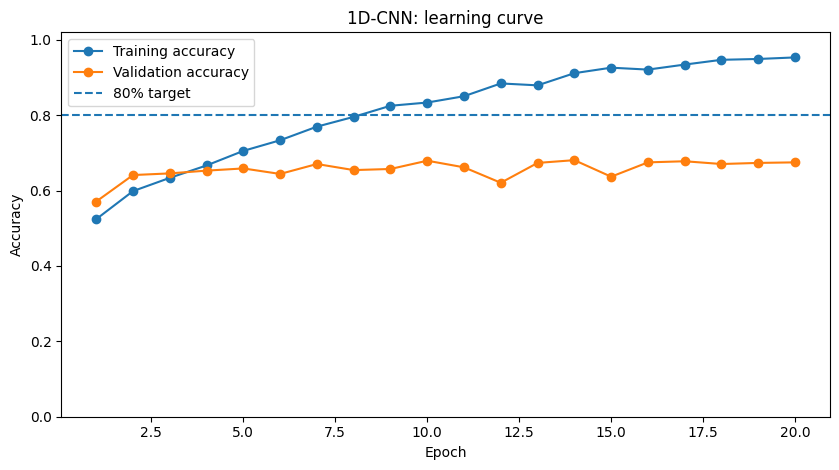

1D-CNN best epoch=14, train acc=0.912, val acc=0.681, gap=0.231
Diagnosis: likely overfitting.


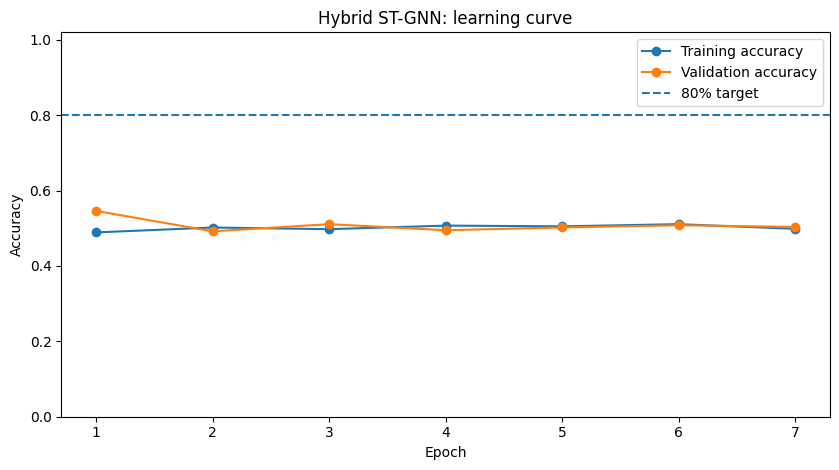

Hybrid ST-GNN best epoch=1, train acc=0.489, val acc=0.546, gap=-0.057
Diagnosis: likely underfitting.


In [24]:
for model_name, model_history in history_all.groupby("model"):
    plt.figure(figsize=(8.5, 4.8))
    plt.plot(
        model_history["epoch"],
        model_history["train_accuracy"],
        marker="o",
        label="Training accuracy",
    )
    plt.plot(
        model_history["epoch"],
        model_history["val_accuracy"],
        marker="o",
        label="Validation accuracy",
    )
    plt.axhline(
        TARGET_ACCURACY,
        linestyle="--",
        label="80% target",
    )
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{model_name}: learning curve")
    plt.ylim(0, 1.02)
    plt.legend()
    plt.tight_layout()
    safe_name = re.sub(
        r"[^a-zA-Z0-9]+", "_", model_name
    ).strip("_").lower()
    plt.savefig(
        FIGURE_DIR / f"{safe_name}_learning_curve.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()

    best_row = model_history.loc[
        model_history["val_f1_macro"].idxmax()
    ]
    gap = (
        float(best_row["train_accuracy"])
        - float(best_row["val_accuracy"])
    )
    print(
        f"{model_name} best epoch={int(best_row['epoch'])}, "
        f"train acc={best_row['train_accuracy']:.3f}, "
        f"val acc={best_row['val_accuracy']:.3f}, "
        f"gap={gap:.3f}"
    )
    if best_row["train_accuracy"] < 0.75 and best_row["val_accuracy"] < 0.75:
        print("Diagnosis: likely underfitting.")
    elif gap > 0.12:
        print("Diagnosis: likely overfitting.")
    else:
        print("Diagnosis: train/validation fit is reasonably controlled.")


## 22. Deep-model predictions and first comparison


In [25]:
deep_results = []
deep_probability_store = {}

for model_name, model_list in deep_models.items():
    validation_probability_parts = []
    test_probability_parts = []
    validation_inference_times = []
    test_inference_times = []

    for model in model_list:
        val_probs, val_labels_check, _, val_seconds = deep_probabilities(
            model, val_loader
        )
        test_probs, test_labels_check, _, test_seconds = deep_probabilities(
            model, test_loader
        )
        assert np.array_equal(val_labels_check, y_val)
        assert np.array_equal(test_labels_check, y_test)

        validation_probability_parts.append(val_probs)
        test_probability_parts.append(test_probs)
        validation_inference_times.append(val_seconds)
        test_inference_times.append(test_seconds)

    mean_val_probs = np.mean(validation_probability_parts, axis=0)
    mean_test_probs = np.mean(test_probability_parts, axis=0)

    total_training_seconds = sum(
        record["training_seconds"]
        for record in deep_run_records
        if record["model"] == model_name
    )

    deep_results.extend([
        metric_row(
            model_name,
            "validation",
            y_val,
            mean_val_probs,
            total_training_seconds,
            float(np.mean(validation_inference_times)),
            model_family="deep baseline" if model_name == "1D-CNN" else "GNN",
        ),
        metric_row(
            model_name,
            "test",
            y_test,
            mean_test_probs,
            total_training_seconds,
            float(np.mean(test_inference_times)),
            model_family="deep baseline" if model_name == "1D-CNN" else "GNN",
        ),
    ])
    deep_probability_store[model_name] = {
        "validation": mean_val_probs,
        "test": mean_test_probs,
    }

all_results = pd.concat(
    [
        pd.DataFrame(baseline_results),
        pd.DataFrame(deep_results),
    ],
    ignore_index=True,
)

validation_comparison = all_results[
    all_results["split"] == "validation"
].sort_values(
    ["f1_macro", "balanced_accuracy", "accuracy"],
    ascending=False,
)
test_comparison = all_results[
    all_results["split"] == "test"
].sort_values(
    ["f1_macro", "balanced_accuracy", "accuracy"],
    ascending=False,
)

print("BASELINE TO BEAT:", BASELINE_TO_BEAT)
print(
    "Selected from validation data only; validation macro F1 =",
    f"{BASELINE_TO_BEAT_VAL_F1:.4f}",
)
print("\nValidation comparison:")
display(validation_comparison)
print("\nTest comparison:")
display(test_comparison)

all_results.to_csv(
    OUTPUT_DIR / "task2_complete_model_comparison.csv",
    index=False,
)


BASELINE TO BEAT: Logistic Regression
Selected from validation data only; validation macro F1 = 0.6602

Validation comparison:


,model,family,split,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,mcc,cohen_kappa,log_loss,training_seconds,inference_seconds,roc_auc
20,1D-CNN,deep baseline,validation,0.680820,0.680659,0.681669,0.680659,0.680320,0.680376,0.362327,0.361430,1.348961,35.193357,0.267760,0.733751
0,Logistic Regression,baseline,validation,0.660322,0.660431,0.660804,0.660431,0.660158,0.660125,0.321235,0.320788,0.730162,0.911983,0.001514,0.696999
14,MLP,baseline,validation,0.653001,0.653091,0.653328,0.653091,0.652894,0.652868,0.306419,0.306123,0.872576,2.328184,0.002337,0.698945
16,XGBoost,baseline,validation,0.644217,0.644332,0.644709,0.644332,0.644021,0.643985,0.289041,0.288594,0.683638,17.489722,0.011024,0.688853
18,Motor-area CSP-LDA,baseline,validation,0.642753,0.642939,0.643938,0.642939,0.642193,0.642131,0.286875,0.285767,0.636699,13.859758,0.027595,0.693123
12,Extra Trees,baseline,validation,0.641288,0.641275,0.641280,0.641275,0.641276,0.641285,0.282555,0.282554,0.646941,25.791435,0.227672,0.679009
10,Gradient Boosting,baseline,validation,0.636896,0.636863,0.636896,0.636863,0.636858,0.636874,0.273759,0.273741,0.637923,92.521166,0.004162,0.691494
8,Random Forest,baseline,validation,0.632504,0.632477,0.632498,0.632477,0.632475,0.632489,0.264975,0.264965,0.641628,13.204410,0.176707,0.681418
2,RBF SVM,baseline,validation,0.632504,0.632786,0.634973,0.632786,0.631109,0.631009,0.267750,0.265418,0.696778,9.163241,0.632356,0.686872
4,k-NN,baseline,validation,0.585652,0.586100,0.589819,0.586100,0.581503,0.581320,0.175879,0.172043,0.754339,0.001517,0.196398,0.650171



Test comparison:


,model,family,split,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,mcc,cohen_kappa,log_loss,training_seconds,inference_seconds,roc_auc
21,1D-CNN,deep baseline,test,0.659605,0.659634,0.659640,0.659634,0.659604,0.659601,0.319273,0.319242,1.146694,35.193357,0.680316,0.707873
17,XGBoost,baseline,test,0.642655,0.642620,0.642644,0.642620,0.642620,0.642640,0.285264,0.285254,0.687750,17.489722,0.006925,0.677972
9,Random Forest,baseline,test,0.642655,0.642508,0.642915,0.642508,0.642341,0.642401,0.285423,0.285094,0.639987,13.204410,0.172895,0.681842
19,Motor-area CSP-LDA,baseline,test,0.641243,0.641216,0.641229,0.641216,0.641217,0.641234,0.282445,0.282440,0.722633,13.859758,0.028094,0.667606
13,Extra Trees,baseline,test,0.638418,0.638167,0.639301,0.638167,0.637582,0.637681,0.277466,0.276467,0.641253,25.791435,0.218302,0.679436
11,Gradient Boosting,baseline,test,0.635593,0.635390,0.636120,0.635390,0.635022,0.635104,0.271509,0.270884,0.649346,92.521166,0.003786,0.674788
1,Logistic Regression,baseline,test,0.618644,0.618600,0.618630,0.618600,0.618595,0.618620,0.237230,0.237215,0.853860,0.911983,0.001087,0.646083
15,MLP,baseline,test,0.617232,0.617100,0.617367,0.617100,0.616956,0.617014,0.234466,0.234256,1.101924,2.328184,0.002238,0.649930
3,RBF SVM,baseline,test,0.611582,0.611625,0.611644,0.611625,0.611575,0.611566,0.223269,0.223226,0.720971,9.163241,0.648936,0.657822
7,Decision Tree,baseline,test,0.577684,0.577439,0.578035,0.577439,0.576764,0.576876,0.155472,0.154949,3.831617,1.913015,0.000434,0.589584


## 23. Final test report for the Hybrid ST-GNN

The following report is the first-results comparison requested in Task 2. It should be presented together with the baseline table and the named baseline to beat.


              precision    recall  f1-score   support

   Left fist     0.5097    0.6629    0.5763       356
  Right fist     0.5102    0.3551    0.4188       352

    accuracy                         0.5099       708
   macro avg     0.5100    0.5090    0.4975       708
weighted avg     0.5100    0.5099    0.4980       708



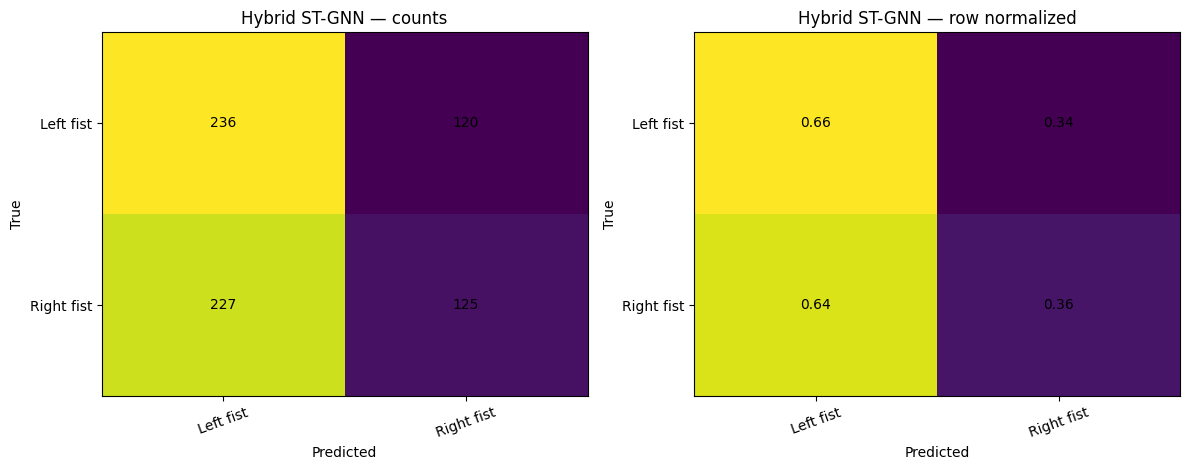

,comparison,model,test_accuracy,test_balanced_accuracy,test_macro_f1,accuracy_difference_vs_baseline
0,Baseline to beat,Logistic Regression,0.618644,0.618600,0.618595,0.000000
1,Proposed model,Hybrid ST-GNN,0.509887,0.509017,0.497537,-0.108757


In [26]:
final_test_probs = deep_probability_store["Hybrid ST-GNN"]["test"]
final_test_pred = final_test_probs.argmax(axis=1)

print(
    classification_report(
        y_test,
        final_test_pred,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0,
    )
)

confusion = confusion_matrix(
    y_test,
    final_test_pred,
    labels=np.arange(N_CLASSES),
)
row_normalized = confusion / np.maximum(
    confusion.sum(axis=1, keepdims=True), 1
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for axis, matrix, title, value_format in [
    (axes[0], confusion, "Hybrid ST-GNN — counts", "d"),
    (axes[1], row_normalized, "Hybrid ST-GNN — row normalized", ".2f"),
]:
    image = axis.imshow(matrix, aspect="auto")
    axis.set_xlabel("Predicted")
    axis.set_ylabel("True")
    axis.set_title(title)
    axis.set_xticks(range(N_CLASSES), CLASS_NAMES, rotation=20)
    axis.set_yticks(range(N_CLASSES), CLASS_NAMES)
    for row in range(N_CLASSES):
        for column in range(N_CLASSES):
            value = (
                int(matrix[row, column])
                if value_format == "d"
                else float(matrix[row, column])
            )
            axis.text(
                column,
                row,
                format(value, value_format),
                ha="center",
                va="center",
            )

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "hybrid_stgnn_test_confusion_matrix.png",
    dpi=220,
    bbox_inches="tight",
)
plt.show()

stgnn_test_row = test_comparison[
    test_comparison["model"] == "Hybrid ST-GNN"
].iloc[0]
baseline_test_row = test_comparison[
    test_comparison["model"] == BASELINE_TO_BEAT
].iloc[0]

first_results_summary = pd.DataFrame([
    {
        "comparison": "Baseline to beat",
        "model": BASELINE_TO_BEAT,
        "test_accuracy": baseline_test_row["accuracy"],
        "test_balanced_accuracy": baseline_test_row["balanced_accuracy"],
        "test_macro_f1": baseline_test_row["f1_macro"],
    },
    {
        "comparison": "Proposed model",
        "model": "Hybrid ST-GNN",
        "test_accuracy": stgnn_test_row["accuracy"],
        "test_balanced_accuracy": stgnn_test_row["balanced_accuracy"],
        "test_macro_f1": stgnn_test_row["f1_macro"],
    },
])
first_results_summary["accuracy_difference_vs_baseline"] = (
    first_results_summary["test_accuracy"]
    - float(baseline_test_row["accuracy"])
)
display(first_results_summary)
first_results_summary.to_csv(
    OUTPUT_DIR / "first_results_baseline_vs_gnn.csv",
    index=False,
)


## 24. Accuracy target and responsible interpretation


In [27]:
stgnn_test_accuracy = float(stgnn_test_row["accuracy"])
stgnn_train_best = history_all[
    history_all["model"] == "Hybrid ST-GNN"
].sort_values("val_f1_macro", ascending=False).iloc[0]

print("Evaluation mode:", EVALUATION_MODE)
print("Hybrid ST-GNN test accuracy:", f"{stgnn_test_accuracy:.2%}")
print("Maximum configured epochs:", MAX_EPOCHS)
assert MAX_EPOCHS <= 20

if stgnn_test_accuracy >= TARGET_ACCURACY:
    print(
        f"SUCCESS: the measured subject-independent test accuracy "
        f"meets the {TARGET_ACCURACY:.0%} target."
    )
else:
    print(
        f"The measured test accuracy is below {TARGET_ACCURACY:.0%}. "
        "This result must be reported honestly; the notebook does not "
        "alter labels, leak subjects, or tune on the test set."
    )

train_val_gap = (
    float(stgnn_train_best["train_accuracy"])
    - float(stgnn_train_best["val_accuracy"])
)
print("Best-epoch train-validation accuracy gap:", f"{train_val_gap:.3f}")

if (
    stgnn_train_best["train_accuracy"] < 0.75
    and stgnn_train_best["val_accuracy"] < 0.75
):
    print(
        "Likely underfitting remains. Valid next steps are graph/feature "
        "ablation, frequency-band tuning on validation data, or more data."
    )
elif train_val_gap > 0.12:
    print(
        "Likely overfitting. Increase regularization or simplify the model."
    )
else:
    print("No strong underfit/overfit signal at the selected checkpoint.")


Evaluation mode: subject_holdout
Hybrid ST-GNN test accuracy: 50.99%
Maximum configured epochs: 20
The measured test accuracy is below 80%. This result must be reported honestly; the notebook does not alter labels, leak subjects, or tune on the test set.
Best-epoch train-validation accuracy gap: -0.057
Likely underfitting remains. Valid next steps are graph/feature ablation, frequency-band tuning on validation data, or more data.


## 25. Export models, predictions, metrics, and presentation assets


In [28]:
export_dataset_path = OUTPUT_DIR / (
    f"{TASK.lower()}_{EVALUATION_MODE}_64ch_graph_dataset.npz"
)
np.savez_compressed(
    export_dataset_path,
    X_full=X_full,
    X_model=X_model,
    node_features=node_features,
    y=y,
    subjects=groups,
    runs=runs,
    annotations=annotations,
    channel_names=np.asarray(channel_names),
    class_names=np.asarray(CLASS_NAMES),
    train_idx=train_idx,
    val_idx=val_idx,
    test_idx=test_idx,
    adjacency=normalized_adjacency,
    anatomical_adjacency=anatomical_adjacency,
    functional_adjacency=functional_adjacency,
    sfreq=np.asarray(TARGET_FS),
    full_tmin=np.asarray(FULL_TMIN),
    full_tmax=np.asarray(FULL_TMAX),
    model_tmin=np.asarray(MODEL_TMIN),
    model_tmax=np.asarray(MODEL_TMAX),
)

prediction_table = metadata.iloc[test_idx].copy().reset_index(drop=True)
prediction_table["true_label"] = y_test
prediction_table["true_class"] = [
    CLASS_NAMES[value] for value in y_test
]
prediction_table["predicted_label"] = final_test_pred
prediction_table["predicted_class"] = [
    CLASS_NAMES[value] for value in final_test_pred
]
prediction_table["correct"] = (
    prediction_table["true_label"]
    == prediction_table["predicted_label"]
)
for class_id, class_name in enumerate(CLASS_NAMES):
    safe_name = re.sub(
        r"[^a-zA-Z0-9]+", "_", class_name
    ).strip("_").lower()
    prediction_table[f"probability_{safe_name}"] = (
        final_test_probs[:, class_id]
    )
prediction_table.to_csv(
    OUTPUT_DIR / "hybrid_stgnn_test_predictions.csv",
    index=False,
)

split_summary.to_csv(
    OUTPUT_DIR / "split_summary.csv",
    index=False,
)
metadata.to_csv(
    OUTPUT_DIR / "all_trial_metadata.csv",
    index=False,
)
rejected.to_csv(
    OUTPUT_DIR / "rejected_events.csv",
    index=False,
)

summary_payload = {
    "task": TASK,
    "evaluation_mode": EVALUATION_MODE,
    "target_accuracy": TARGET_ACCURACY,
    "max_epochs": MAX_EPOCHS,
    "baseline_to_beat": BASELINE_TO_BEAT,
    "baseline_validation_macro_f1": BASELINE_TO_BEAT_VAL_F1,
    "hybrid_stgnn_test_accuracy": stgnn_test_accuracy,
    "hybrid_stgnn_test_balanced_accuracy": float(
        stgnn_test_row["balanced_accuracy"]
    ),
    "hybrid_stgnn_test_macro_f1": float(
        stgnn_test_row["f1_macro"]
    ),
    "subject_overlap": overlaps,
    "train_subjects": int(len(np.unique(groups[train_idx]))),
    "validation_subjects": int(len(np.unique(groups[val_idx]))),
    "test_subjects": int(len(np.unique(groups[test_idx]))),
}
with open(
    OUTPUT_DIR / "task2_summary.json",
    "w",
    encoding="utf-8",
) as handle:
    json.dump(summary_payload, handle, indent=2)

print("Exported dataset:", export_dataset_path)
print("Output directory:", OUTPUT_DIR)
print("\nMain presentation files:")
for filename in [
    "task2_complete_model_comparison.csv",
    "first_results_baseline_vs_gnn.csv",
    "baseline_full_metrics.csv",
    "deep_training_history.csv",
    "hybrid_stgnn_test_predictions.csv",
    "task2_summary.json",
    "figures/stgnn_architecture_diagram.png",
    "figures/hybrid_stgnn_test_confusion_matrix.png",
]:
    print(" -", OUTPUT_DIR / filename)


Exported dataset: /kaggle/working/eeg_task2_output/lr_execution_subject_holdout_64ch_graph_dataset.npz
Output directory: /kaggle/working/eeg_task2_output

Main presentation files:
 - /kaggle/working/eeg_task2_output/task2_complete_model_comparison.csv
 - /kaggle/working/eeg_task2_output/first_results_baseline_vs_gnn.csv
 - /kaggle/working/eeg_task2_output/baseline_full_metrics.csv
 - /kaggle/working/eeg_task2_output/deep_training_history.csv
 - /kaggle/working/eeg_task2_output/hybrid_stgnn_test_predictions.csv
 - /kaggle/working/eeg_task2_output/task2_summary.json
 - /kaggle/working/eeg_task2_output/figures/stgnn_architecture_diagram.png
 - /kaggle/working/eeg_task2_output/figures/hybrid_stgnn_test_confusion_matrix.png


## 26. Presentation-ready explanation in your own words

**Problem.** The goal is to classify left- versus right-fist motor execution from 64-channel EEG without allowing trials from the same participant to appear in multiple splits.

**Baselines.** I first converted every trial into interpretable spectral and temporal features. Missing values, scaling, and feature selection were fitted only on the training subjects. I compared general machine-learning models, a neural MLP, a 1D-CNN, and the EEG-specific CSP-LDA method. The model with the highest validation macro F1 became the baseline to beat.

**Graph.** Every electrode is a node. Anatomical edges connect nearby electrodes, while functional edges connect channels that are highly correlated in the training data. Their weighted combination represents both scalp geometry and coordinated brain activity.

**GNN.** The temporal layers learn patterns across the four-second EEG sequence. Graph propagation then shares information between connected electrodes. Attention pooling identifies the most useful electrodes, and a second graph branch processes handcrafted node features. The two branches are fused to predict the class.

**Fit control.** Training is capped at 20 epochs. Early stopping, mild augmentation, class-weighted loss, dropout, weight decay, and validation-only checkpoint selection control overfitting. The learning curves and train-validation gap are used to diagnose remaining underfitting or overfitting.

**Reporting rule.** The subject-independent test result is the main result. A random trial split may be run only as a secondary diagnostic and must not be presented as unseen-subject performance.
